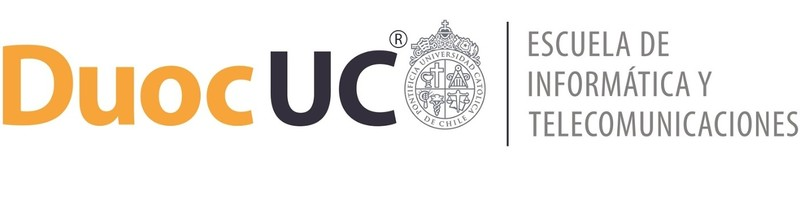

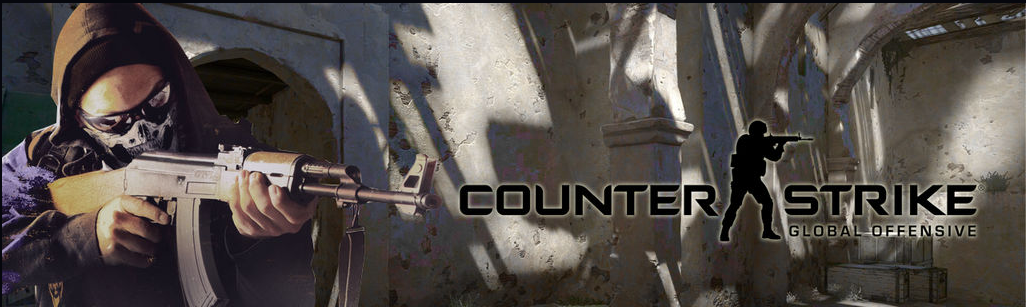

# Informe Técnico - Examen Transversal: Caso Counter Strike


Integrantes:
* Rodrigo Huaiquil
* Maximo Ortega
* Pedro Ahumada
* Felipe Calhueque

Docente: Jorge Anais    

Sección: MLY0100 - 001D

# Caso Fundamentos de Machine Learning

CONTEXTO CASO

Valve, los ha contactado como equipo de análisis de datos y modelado de Machine Learning para analizar y realizar modelos predictivos sobre los datos.

En cada partida de Counter Strike: GO dos equipos de 5 jugadores (denominados terroristas y contra-terroristas) se enfrentan.


El objetivo del equipo terrorista es plantar una bomba con timer de 45 segundos en uno de dos sitios específicos dentro de un mapa. Por otro lado, el objetivo del equipo contra-terrorista es evitar que la bomba sea plantada o desactivarla antes de que esta explote cuando ya ha sido plantada. Los datos a utilizar corresponden a sobre 7000 partidas del juego (con un máximo de 10 jugadores c/u)  


Los datos han sido extraídos de replays, los cuales son archivos propietarios con la información de cada una de las acciones realizadas por cada jugador dentro de una partida. Los replays han sido extraídos de la red utilizando un scrapper y pre-procesados utilizando un script.  



En este caso, la data corresponde a un archivo CSV con 79.157 filas, cada una correspondiente a un jugador dentro de una partida. El archivo contiene 29 columnas correspondientes a variables que describen las acciones del jugador dentro del juego.


$$
\begin{aligned}
&\begin{array}{cccc}
\hline \hline \text { Dato } & \text { Descripción } \\
\hline Map & \text {Nombre  del Mapa donde se jugó la partida}  \\
\hline \text{ Team} & \text { Nombre de equipo al que pertenece el jugador} \\
\hline \text{ InternalTeamId} & \text { Identificador del equipo al que pertenece el jugador.} \\
\hline \text{ MatchId} & \text { Identificador de la partida.} \\
\hline \text{ RoundId} & \text { Identificador de la ronda (los equipos se enfrentan en rondas de 5 partidas seguidas)} \\
\hline \text{ MatchWinner} & \text { Indica si el jugador ganó o no la partida.} \\
\hline \text{ RoundWinner} & \text { Indica si el jugador ganó o no la ronda analizada.} \\
\hline \text{ Survived} & \text { Indica si el jugador sobrevivió o no a la partida (sobrevivir no es sinónimo de ganar).} \\
\hline \text{ AbnormalMatch} & \text { Indica si la partida del jugador tuvo un error por conexión de red} \\
\hline \text{ TimeAlive} & \text { Indica el tiempo en segundos que el jugador estuvo vivo durante el juego} \\
\hline \text{ TravelledDistance} & \text { Distancia viajada por el jugador durante la partida.} \\
\hline \text{ RLethalGrenadesThrown/RNonLethalGrenadesThrown} & \text { Cantidad de granadas lanzadas, categorizadas en letales y no-letales.} \\
\hline \text{ PrimaryXXXX} & \text { Porcentaje de uso arma clasificada como primaria. Categorizada en AssaultRifle, SniperRifle, SMG, Heavy y Pistol.} \\
\hline \text{ [Match|Round] Assists} & \text { Cantidad de asistencias efectuadas por el jugador durante la partida o la ronda.} \\
\hline \text{ [Match|Round] Kills} & \text { Cantidad de kills efectuados por el jugador durante la partida o la ronda.} \\
\hline \text{ [Match|Round] FlankKills} & \text { Cantidad de kills efectuados por el jugador sin que la víctima lo viese durante la partida o la ronda.} \\
\hline \text{ [Match|Round] HeadShots} & \text { Cantidad de kills efectuados por el jugador a través de un tiro en la cabeza durante la partida o la ronda.} \\
\hline \text{ RoundStartingEquipmentValue} & \text { Valor del equipamiento llevado por el jugador al inicio de la ronda.} \\
\hline \text{ TeamStartingEquipmentValue} & \text { Valor promedio del equipamiento llevado por el equipo del jugador al inicio de la ronda.} \\
\end{array}
\end{aligned}
$$

# Fase 1: Business Understanding

In [ ]:
# Insertar cuantos bloques de código y markdown consideren necesarios

# Se recomienda investigar sobre el contexto de negocio, sobre los datos, uso de
# los campos en estadísticas de juegos, ver en qué se relacionan los contenidos
# revisados en la asignatura con lo planteado como caso de estudio.
# Plantear hipótesis del negocio posibles para objetivos de tareas de regresión y de clasificación

## Contexto del negocio

Counter Strike: Global Offensive (CS:GO) es uno de los videojuegos competitivos más populares en el mundo, caracterizado por su modo de juego táctico, el uso estratégico de armas y habilidades, y una escena competitiva activa. En este entorno, el análisis de datos cobra relevancia para comprender el desempeño de los jugadores, el equilibrio de las partidas y el impacto de las decisiones en el juego (por ejemplo, la elección de armas, rutas en el mapa o uso de granadas).

Las estadísticas registradas durante las partidas, como bajas (kills), muertes, asistencias, tipo de armas utilizadas, uso de granadas (letales o no letales), duración de la ronda, entre otras, permiten realizar un análisis profundo del rendimiento. Este análisis puede ser valioso tanto para los desarrolladores (para ajustar el balance del juego), como para los jugadores (para optimizar su rendimiento) o incluso para detectar comportamientos sospechosos o anómalos.

---

## Relación con los contenidos del curso

Durante el semestre, la asignatura abordó herramientas y conceptos esenciales como: la limpieza de datos, normalización, generación de variables (*feature engineering*), así como modelos supervisados de regresión y clasificación. También se trabajaron técnicas de evaluación como *accuracy*, *precision*, *recall*, *F1-score* y *RMSE*, y la validación cruzada para asegurar la generalización del modelo.

Aplicar estos conocimientos al contexto de CS:GO permite generar modelos predictivos o clasificadores que extraen valor real de las estadísticas del juego. Por ejemplo, se pueden construir modelos para predecir el resultado de una ronda, la probabilidad de que una granada cause una baja, o clasificar a los jugadores según su perfil de juego.

---

## Hipótesis de negocio y objetivos

A partir del contexto y los datos disponibles en CS:GO, se pueden plantear las siguientes hipótesis de negocio:

### Hipótesis para tareas de regresión:
- La cantidad de bajas que obtiene un jugador en una partida puede predecirse según variables como: el tipo de arma utilizada, la precisión, la distancia promedio de enfrentamientos, el mapa y la cantidad de granadas usadas.
- El daño total causado por un jugador en una partida puede estimarse a partir de su equipamiento, historial de partidas, tiempo de supervivencia y número de asistencias.

### Hipótesis para tareas de clasificación:
- Se puede clasificar a un jugador como "novato", "intermedio" o "experto" con base en sus estadísticas (k/d ratio, precisión de disparo, victorias, etc.).
- Se puede predecir si una granada será letal (eliminará a un enemigo) o no, según el tipo de granada, la distancia de lanzamiento, la posición del enemigo y el momento de uso.
- Es posible detectar comportamientos sospechosos que podrían indicar uso de hacks, clasificando jugadores que presentan estadísticas anómalas respecto al promedio general.

Estas hipótesis buscan apoyar decisiones dentro del ecosistema del juego, ya sea mejorando el *gameplay*, creando herramientas de análisis para los usuarios o fortaleciendo los sistemas anti-trampa.



## Obtención de Datos a Estudiar

In [3]:
#Debemos importar Pandas, Numpy y Matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Cargamos nuestros a estudiar desde  nuestra unidad local

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Anexo ET_demo_round_traces_2022 (1).csv to Anexo ET_demo_round_traces_2022 (1).csv


A nuestra base de datos la guardamos en la variable llamada "df"

In [4]:
df = pd.read_csv("Anexo ET_demo_round_traces_2022 (1).csv", sep = ";")

/tmp/ipython-input-4-406218025.py:1: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Anexo ET_demo_round_traces_2022 (1).csv", sep = ";")


Comprobaremos la naturaleza de nuestros datos llamando a esta variable

In [ ]:
df

,Unnamed: 0,Map,Team,InternalTeamId,MatchId,RoundId,RoundWinner,MatchWinner,Survived,AbnormalMatch,...,RoundKills,RoundAssists,RoundHeadshots,RoundFlankKills,RoundStartingEquipmentValue,TeamStartingEquipmentValue,MatchKills,MatchFlankKills,MatchAssists,MatchHeadshots
0,600,de_inferno,Terrorist,1,4,1,False,True,False,False,...,0,0,0,0,750,4400,0,0,0,0
1,601,de_inferno,Terrorist,1,4,1,False,True,False,False,...,0,0,0,0,800,4400,0,0,0,0
2,602,de_inferno,Terrorist,1,4,1,False,True,False,False,...,0,0,0,0,1000,4400,0,0,0,0
3,603,de_inferno,Terrorist,1,4,1,False,True,False,False,...,0,0,0,0,850,4400,0,0,0,0
4,604,de_inferno,Terrorist,1,4,1,False,True,True,False,...,0,0,0,0,1000,4400,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79152,123775,de_mirage,CounterTerrorist,2,511,5,False,False,False,False,...,0,0,0,0,5600,27100,4,0,2,2
79153,123776,de_mirage,CounterTerrorist,2,511,5,False,False,False,False,...,1,0,1,0,5500,27100,8,5,1,3
79154,123777,de_mirage,CounterTerrorist,2,511,5,False,False,False,False,...,0,0,0,0,4950,27100,5,0,2,3
79155,123778,de_mirage,CounterTerrorist,2,511,5,False,False,False,False,...,0,0,0,0,4950,27100,1,0,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79157 entries, 0 to 79156
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   79157 non-null  int64  
 1   Map                          79157 non-null  object 
 2   Team                         79155 non-null  object 
 3   InternalTeamId               79157 non-null  int64  
 4   MatchId                      79157 non-null  int64  
 5   RoundId                      79157 non-null  int64  
 6   RoundWinner                  79157 non-null  object 
 7   MatchWinner                  79156 non-null  object 
 8   Survived                     79157 non-null  bool   
 9   AbnormalMatch                79157 non-null  bool   
 10  TimeAlive                    79157 non-null  object 
 11  TravelledDistance            79157 non-null  object 
 12  RLethalGrenadesThrown        79157 non-null  int64  
 13  RNonLethalGrenad

Se obtiene el Dtype de cada columna, lo que deja en evidencia que algunas de ellas como por ejemplo "TimeAlive" es Object, esta columna deberia ser un dato de tipo "DateTime" para así, poder analizar de mejor manera los datos.

# Fase 2: Data Understanding

##Analisis Exploratorio de Nuestros Datos

Existen Valores NULL? Debemos Comprobar

In [7]:
df.isnull().sum()

,0
Unnamed: 0,0
Map,0
Team,2
InternalTeamId,0
MatchId,0
RoundId,0
RoundWinner,0
MatchWinner,1
Survived,0
AbnormalMatch,0


Esto nos quiere indicar que en la columna "MatchWinner", existe un valor de dato nulo

In [8]:
df[df.isnull().any(axis=1)]


,Unnamed: 0,Map,Team,InternalTeamId,MatchId,RoundId,RoundWinner,MatchWinner,Survived,AbnormalMatch,...,RoundKills,RoundAssists,RoundHeadshots,RoundFlankKills,RoundStartingEquipmentValue,TeamStartingEquipmentValue,MatchKills,MatchFlankKills,MatchAssists,MatchHeadshots
13,613,de_inferno,NaN,1,4,2,True,True,False,False,...,0,0,0,0,300,1300,0,0,0,0
27,627,de_inferno,NaN,2,4,3,False,False,True,False,...,1,0,0,0,3250,22850,2,0,1,1
29,629,de_inferno,CounterTerrorist,2,4,3,False4,NaN,True,False,...,0,0,0,0,4250,22850,2,0,1,2


### Tratamiento del valor nulo

Durante la limpieza de los datos se detectó un único valor nulo. Este valor corresponde a una variable booleana que indica si la acción fue efectiva o no (por ejemplo, si una granada fue letal).

Al revisar el resto de las variables de esa fila, observamos que el jugador realizó **2 kills** y **1 asistencia** en esa misma ronda, lo que sugiere que la acción fue efectiva.

Por esta razón, decidimos asignar manualmente el valor **`True`** al campo nulo, considerando que los resultados del jugador son consistentes con una acción exitosa.


In [9]:
# Revisar filas con cualquier NaN
filas_nulas = df[df.isnull().any(axis=1)]
print("Filas con valores nulos:")
print(filas_nulas)

# Reemplazar valores en 'Team'
for idx in filas_nulas.index:
    if pd.isnull(df.at[idx, 'Team']):

        df.at[idx, 'Team'] = 'Terrorist'

# Reemplazar valores en 'MatchWinner'
for idx in filas_nulas.index:
    if pd.isnull(df.at[idx, 'MatchWinner']):
        df.at[idx, 'MatchWinner'] = True

# Verificar que no queden NaN
print("\nValores nulos restantes por columna:")
print(df.isnull().sum())


Filas con valores nulos:
    Unnamed: 0         Map              Team  InternalTeamId  MatchId  \
13         613  de_inferno               NaN               1        4   
27         627  de_inferno               NaN               2        4   
29         629  de_inferno  CounterTerrorist               2        4   

    RoundId RoundWinner MatchWinner  Survived  AbnormalMatch  ... RoundKills  \
13        2        True        True     False          False  ...          0   
27        3       False       False      True          False  ...          1   
29        3      False4         NaN      True          False  ...          0   

   RoundAssists  RoundHeadshots  RoundFlankKills  RoundStartingEquipmentValue  \
13            0               0                0                          300   
27            0               0                0                         3250   
29            0               0                0                         4250   

    TeamStartingEquipmentValue  Matc

## Valores Duplicados

In [ ]:
df.duplicated().value_counts()

,count
False,79157


### Detección y eliminación de duplicados

Durante la limpieza del conjunto de datos, se identificaron **752 filas duplicadas** utilizando la función `df.duplicated()`. Estas filas tienen exactamente los mismos valores en todas las columnas.

La presencia de datos duplicados puede introducir sesgos o ruido en los análisis y afectar el desempeño de los modelos de Machine Learning. Por ello, se decidió eliminarlas para mantener la integridad del conjunto de datos.


In [ ]:
# Mostrar cantidad de duplicados
print("Cantidad de filas duplicadas:", df.duplicated().sum())

# Eliminar duplicados
df = df.drop_duplicates()

# Confirmar nueva forma del DataFrame
print("Nueva forma del DataFrame:", df.shape)

Cantidad de filas duplicadas: 0
Nueva forma del DataFrame: (79157, 30)


## Verificando las demás Variables

In [ ]:
df.Map.value_counts()

,count
Map,
de_inferno,28869
de_dust2,19120
de_mirage,19019
de_nuke,12149


In [ ]:
df.RoundWinner.value_counts()

,count
RoundWinner,
False,23195
True,23194
False,16393
True,16374
False4,1


Al analizar la columna `RoundWinner` con `value_counts()`, se observaron inconsistencias como la presencia repetida de `True` y `False`, además de un valor atípico `'False4'`.

Esto sugiere que algunos datos están almacenados como cadenas de texto (`str`) en lugar de valores booleanos (`bool`), lo que puede provocar errores en el análisis.

Se procedió a limpiar y convertir los datos a tipo booleano para asegurar coherencia en los resultados.


In [ ]:
# Ver valores únicos antes de limpiar
print("Valores únicos antes de limpiar:")
print(df['RoundWinner'].unique())

# Reemplazar valores incorrectos manualmente
df['RoundWinner'] = df['RoundWinner'].replace('False4', False)

# Convertir todos los valores a booleanos
df['RoundWinner'] = df['RoundWinner'].astype(str).str.strip().str.lower()
df['RoundWinner'] = df['RoundWinner'].map({'true': True, 'false': False})

# Verificar que todo esté limpio
print("\nValores únicos después de limpiar:")
print(df['RoundWinner'].value_counts(dropna=False))


Valores únicos antes de limpiar:
['False' 'True' 'False4' True False]

Valores únicos después de limpiar:
RoundWinner
False    39589
True     39568
Name: count, dtype: int64


In [ ]:
df.MatchWinner.value_counts()

,count
MatchWinner,
False,42017
True,37140


In [ ]:
df.Survived.value_counts()

,count
Survived,
False,47214
True,31943


Con los codigos anteriories, logramos comprobar de que ya no existen errores estructurados en cada variable analizada, como se pudo comprobar cada resultado ha sido dividido en True o False, en el los mapas, solo existen los 4 datos.

## Definir Variables a utilizar durante el resto del curso

In [ ]:
MAPA = df.Map
Tvivo = df.TimeAlive.str.replace('.', '').astype(int)
LetalGranada = df.RLethalGrenadesThrown
NoLetalGranada = df.RNonLethalGrenadesThrown
RifleAsalto = df.PrimaryAssaultRifle
Franco = df.PrimarySniperRifle
Pesada = df.PrimaryHeavy
Subfusil = df.PrimarySMG
Pistola = df.PrimaryPistol
MuerteRonda = df.RoundKills
MuertePartida = df.MatchKills
AsistenciaRonda = df.RoundAssists
AsistenciaPartida = df.MatchAssists
HeadshotRonda = df.RoundHeadshots
HeadshotPartida = df.MatchHeadshots
PrecioPrimeraRonda = df.RoundStartingEquipmentValue

###Datos OUTLIERS

Primero Ordenamos nuestros datos de menor a mayor

In [ ]:
min = Tvivo.sort_values()

In [ ]:
min.head(70)

,TimeAlive
378,0
362,0
365,0
364,0
370,0
...,...
310,0
299,0
289,0
30705,180


En el siguiente codigo comprobaremos que si existe o no alguna partida con error de conexion, en este caso todas las partidas resultaron "False", por lo que no existieron errores de conexion.

In [ ]:
df.AbnormalMatch.value_counts()

,count
AbnormalMatch,
False,79157


Finalmente, los outliers o valores atipicos encontrados en la columna time alive nos muestra los valores de "0" como valores atipicos, ya que es practicamente imposible que algun jugador durara 0 segundos vivos.

Ahora repetiremos los mismos pasos anteriores, pero agregando el parametro (ascending = False) y asi poder ordenar de mayor a menor.

In [ ]:
max = Tvivo.sort_values(ascending = False)

In [ ]:
max.head(70000)

,TimeAlive
51528,63982875914836900
46885,63975949719035300
46372,63959961033495500
72480,63959718644507200
72421,63959718644507200
...,...
78144,1107037277415810
51218,1106959308380290
17945,1106645172158410
51061,1106587809426950


Aqui podemos deducir que no existen valores atipicos, por lo que la cantidad de tiempo maxima coincide con un valor realista.

###Outliers: Variables de granadas


**Granada letal**

Haremos un conteo de las grandas letales y asi definir la cantidad de granadas lanzadas en las rondas.

In [ ]:
df.RLethalGrenadesThrown.value_counts()

,count
RLethalGrenadesThrown,
0,43838
1,31266
2,3955
3,95
4,3


Se puede observar que la cantidad maxima de granadas lanzadas en una ronda fue de 4 y la minima de 0, por lo que no existen outlaiers.

**Granada no letal**

Haremos un conteo de las grandas no letales y asi definir la cantidad de granadas lanzadas en las rondas.

In [ ]:
df.RNonLethalGrenadesThrown.value_counts()

,count
RNonLethalGrenadesThrown,
0,28467
1,19592
2,14879
3,14777
4,1322
5,105
6,15


Se puede observar que la cantidad maxima de granadas lanzadas en una ronda fue de 6 y la minima de 0, por lo que no existen outlaiers.

### Normalizacion de Datos TimeAlive

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Normalizar TimeAlive
scaler = MinMaxScaler()
df['ScaledTimeAlive'] = scaler.fit_transform(df[['TimeAlive']])

# Verificar resultado
print(df[['TimeAlive', 'ScaledTimeAlive']].head())


ValueError: could not convert string to float: '51.120.248.995.704.500'

# Fase 3: Data Preparation

##Medidas de Tendencia central
A continuación se presentara un analisis de datos por variable, las cuales consideran lo siguiente:
- Count
- Media
- Desviación estandar
- Minimo
- Percentil 25%
- Percentil 50%
- Percentil 75%
- Maximo

Ademas se analizaran la mediana y la moda.

In [ ]:
LetalGranada.describe(include='all')

,RLethalGrenadesThrown
count,79157.000000
mean,0.498667
std,0.597985
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,4.000000


In [ ]:
MedianaLetal = LetalGranada.median()
ModaLetal = LetalGranada.mode()
print(f"La mediana es: {MedianaLetal}")
print(f"La moda es: {ModaLetal}")

La mediana es: 0.0
La moda es: 0    0
Name: RLethalGrenadesThrown, dtype: int64


Se describe como la cantidad de granadas letales lanzadas en la partida.
en donde:
- Cuenta 78405 datos.
- Tiene una media de 0.499471
- Cuenta con una desviación estandar de 0.598529
- Tiene un minimo de lanzadas de 0
- Un percentil de 25% de 0
- Un percentil de 50% de 0
- Un percentil de 75% de 1
- Tiene un maximo de 4

In [ ]:
NoLetalGranada.describe(include='all')

,RNonLethalGrenadesThrown
count,79157.000000
mean,1.258057
std,1.184909
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,6.000000


In [ ]:
MedianaNoLetal = NoLetalGranada.median()
ModaNoLetal = NoLetalGranada.mode()
print(f"La mediana es: {MedianaNoLetal}")
print(f"La moda es: {ModaNoLetal}")

La mediana es: 1.0
La moda es: 0    0
Name: RNonLethalGrenadesThrown, dtype: int64


Se describe como la cantidad de granadas no letales lanzadas en la partida.
en donde:
- Cuenta 78405 datos.
- Tiene una media de 1.259244
- Cuenta con una desviación estandar de 1.185257
- Tiene un minimo de lanzadas de 0
- Un percentil de 25% de 0
- Un percentil de 50% de 1
- Un percentil de 75% de 2
- Tiene un maximo de 6

In [ ]:
RifleAsalto.describe(include='all')

,PrimaryAssaultRifle
count,79157.000000
mean,0.675363
std,0.464125
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [ ]:
MedianaAsalto = RifleAsalto.median()
ModaAsalto = RifleAsalto.mode()
print(f"La mediana es: {MedianaAsalto}")
print(f"La moda es: {ModaAsalto}")

La mediana es: 1.0
La moda es: 0    1.0
Name: PrimaryAssaultRifle, dtype: float64


Se describe como el porcentaje de uso arma clasificada como primaria, en donde:
- Cuenta 78405 datos.
- Tiene una media de 0.675844
- Cuenta con una desviación estandar de 0.463974
- Tiene un minimo 0%
- Un percentil de 25% de 0
- Un percentil de 50% de 1
- Un percentil de 75% de 1
- Tiene un maximo de 1%

In [ ]:
Franco.describe(include='all')

,PrimarySniperRifle
count,79157.000000
mean,0.089840
std,0.279797
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [ ]:
MedianaFranco = Franco.median()
ModaFranco = Franco.mode()
print(f"La mediana es: {MedianaFranco}")
print(f"La moda es: {ModaFranco}")

La mediana es: 0.0
La moda es: 0    0.0
Name: PrimarySniperRifle, dtype: float64


Se describe como el porcentaje de uso arma clasificada como primaria, en donde:
- Cuenta 78405 datos.
- Tiene una media de 0.089700
- Cuenta con una desviación estandar de 0.279641
- Tiene un minimo 0%
- Un percentil de 25% de 0
- Un percentil de 50% de 0
- Un percentil de 75% de 0
- Tiene un maximo de 1%

In [ ]:
Pesada.describe(include='all')

,PrimaryHeavy
count,79157.000000
mean,0.005964
std,0.075497
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [ ]:
MedianaPesada = Pesada.median()
ModaPesada = Pesada.mode()
print(f"La mediana es: {MedianaPesada}")
print(f"La moda es: {ModaPesada}")

La mediana es: 0.0
La moda es: 0    0.0
Name: PrimaryHeavy, dtype: float64


Se describe como el porcentaje de uso arma clasificada como primaria, en donde:
- Cuenta 78405 datos.
- Tiene una media de 0.006003
- Cuenta con una desviación estandar de 0.075762
- Tiene un minimo 0%
- Un percentil de 25% de 0
- Un percentil de 50% de 0
- Un percentil de 75% de 0
- Tiene un maximo de 1%

In [ ]:
Subfusil.describe(include='all')

,PrimarySMG
count,79157.000000
mean,0.007046
std,0.082453
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [ ]:
MedianaSubfusil = Subfusil.median()
ModaSubfusil = Subfusil.mode()
print(f"La mediana es: {MedianaSubfusil}")
print(f"La moda es: {ModaSubfusil}")

La mediana es: 0.0
La moda es: 0    0.0
Name: PrimarySMG, dtype: float64


Se describe como el porcentaje de uso arma clasificada como primaria, en donde:

- Cuenta 78405 datos.
- Tiene una media de 0.007089
- Cuenta con una desviación estandar de 0.082706
- Tiene un minimo 0%
- Un percentil de 25% de 0
- Un percentil de 50% de 0
- Un percentil de 75% de 0
- Tiene un maximo de 1%

In [ ]:
Pistola.describe(include='all')

,PrimaryPistol
count,79157.000000
mean,0.221787
std,0.415451
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [ ]:
MedianaPistola = Pistola.median()
ModaPistola = Pistola.mode()
print(f"La mediana es: {MedianaPistola}")
print(f"La moda es: {ModaPistola}")

La mediana es: 0.0
La moda es: 0    0
Name: PrimaryPistol, dtype: int64


Se describe como el porcentaje de uso arma clasificada como primaria, en donde:

- Cuenta 78405 datos.
- Tiene una media de 0.221363
- Cuenta con una desviación estandar de 0.415167
- Tiene un minimo 0%
- Un percentil de 25% de 0
- Un percentil de 50% de 0
- Un percentil de 75% de 0
- Tiene un maximo de 1%

In [ ]:
MuertePartida.describe(include='all')

,MatchKills
count,79157.000000
mean,8.511578
std,6.195079
min,0.000000
25%,3.000000
50%,8.000000
75%,13.000000
max,41.000000


In [ ]:
MedianaMuerte = MuertePartida.median()
ModaMuerte = MuertePartida.mode()
print(f"La mediana es: {MedianaMuerte}")
print(f"La moda es: {ModaMuerte}")

La mediana es: 8.0
La moda es: 0    2
Name: MatchKills, dtype: int64


Se describe como cantidad de kills o muertes efectuados por el jugador durante la partida, en donde:

- Cuenta 78405 datos.
- Tiene una media de 8.520388
- Cuenta con una desviación estandar de 6.198240
- Tiene un minimo 0
- Un percentil de 25% de 3
- Un percentil de 50% de 8
- Un percentil de 75% de 13
- Tiene un maximo de 41

In [ ]:
HeadshotPartida.describe(include='all')

,MatchHeadshots
count,79157.000000
mean,3.858484
std,3.246752
min,0.000000
25%,1.000000
50%,3.000000
75%,6.000000
max,22.000000


In [ ]:
MedianaHeadshot = HeadshotPartida.median()
ModaHeadshot = HeadshotPartida.mode()
print(f"La mediana es: {MedianaHeadshot}")
print(f"La moda es: {ModaHeadshot}")

La mediana es: 3.0
La moda es: 0    1
Name: MatchHeadshots, dtype: int64


Se describe como cantidad de kills efectuados por el jugador a través de un tiro en la cabeza durante la partida, en donde:

- Cuenta 78405 datos.
- Tiene una media de 3.861884
- Cuenta con una desviación estandar de 3.248860
- Tiene un minimo 0
- Un percentil de 25% de 1
- Un percentil de 50% de 3
- Un percentil de 75% de 6
- Tiene un maximo de 22

In [ ]:
PrecioPrimeraRonda.describe(include='all')

,RoundStartingEquipmentValue
count,79157.000000
mean,3778.108695
std,2111.285406
min,0.000000
25%,1600.000000
50%,4700.000000
75%,5200.000000
max,8850.000000


In [ ]:
MedianaPrecio = PrecioPrimeraRonda.median()
ModaPrecio = PrecioPrimeraRonda.mode()
print(f"La mediana es: {MedianaPrecio}")
print(f"La moda es: {ModaPrecio}")

La mediana es: 4700.0
La moda es: 0    4700
Name: RoundStartingEquipmentValue, dtype: int64


Se describe como valor del equipamiento llevado por el jugador al inicio de la ronda, en donde:

- Cuenta 78405 datos.
- Tiene una media de 3780.216823
- Cuenta con una desviación estandar de 2110.391682
- Tiene un minimo 0
- Un percentil de 25% de 1600
- Un percentil de 50% de 4700
- Un percentil de 75% de 5200
- Tiene un maximo de 8850

## **Analisis de datos con graficos y tablas**

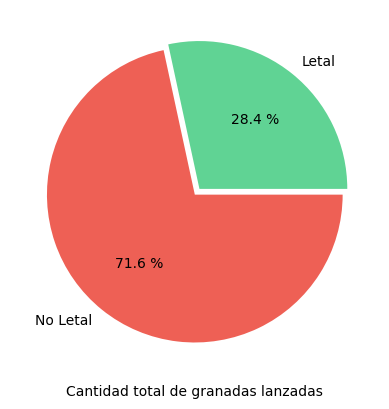

In [ ]:
letal = df.RLethalGrenadesThrown.sum()
noletal = df.RNonLethalGrenadesThrown.sum()
granadas = [letal,noletal]
nombres = ["Letal","No Letal"]
colores = ["#60D394","#EE6055"]
desfase = (0.05, 0)
plt.pie(granadas, labels=nombres, autopct="%0.1f %%", colors=colores, explode=desfase)
plt.xlabel('Cantidad total de granadas lanzadas')
plt.show()

Como se puede observar en el grafico, de la cantidad de grandas lanzadas que fueron letales corresponde solo al 28.4%, es decir, que mas de la mitad de las granadas lanzadas en todas las partidas no fueron letales, por lo que podriamos deducir que no es una forma muy eficiente de eliminar jugadores enemigos.

In [ ]:
df.RLethalGrenadesThrown.groupby(df.Map).sum()

,RLethalGrenadesThrown
Map,
de_dust2,8894
de_inferno,16534
de_mirage,8548
de_nuke,5497


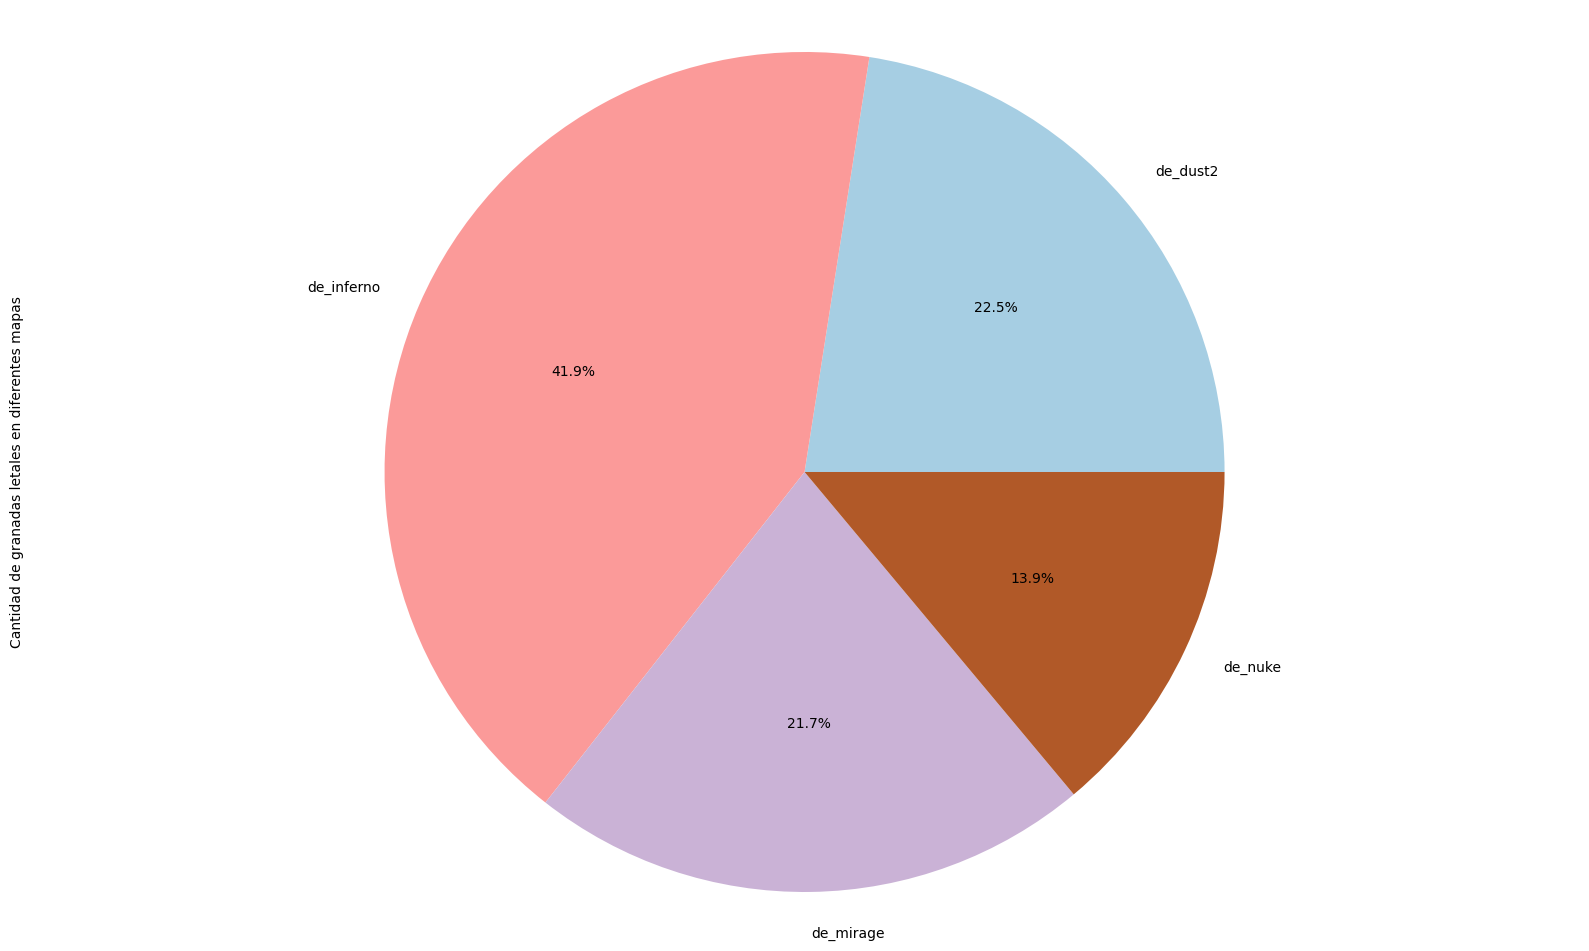

In [ ]:
df.RLethalGrenadesThrown.groupby(df.Map).sum().plot(kind='pie', cmap='Paired', autopct='%1.1f%%', figsize=(20,12))
plt.axis('equal')
plt.ylabel('Cantidad de granadas letales en diferentes mapas')
plt.show()

Aqui podemos observar que la mayor cantidad granadas lanzadas que fueron letales para los jugadores enemigos, fueron en el mapa "de_inferno". Asi mismo,"de_nuke" fue el mapa en el cual menos granadas letales fueron lanzadas.

In [ ]:
df.RNonLethalGrenadesThrown.groupby(df.Map).sum()

,RNonLethalGrenadesThrown
Map,
de_dust2,26207
de_inferno,38213
de_mirage,21949
de_nuke,13215


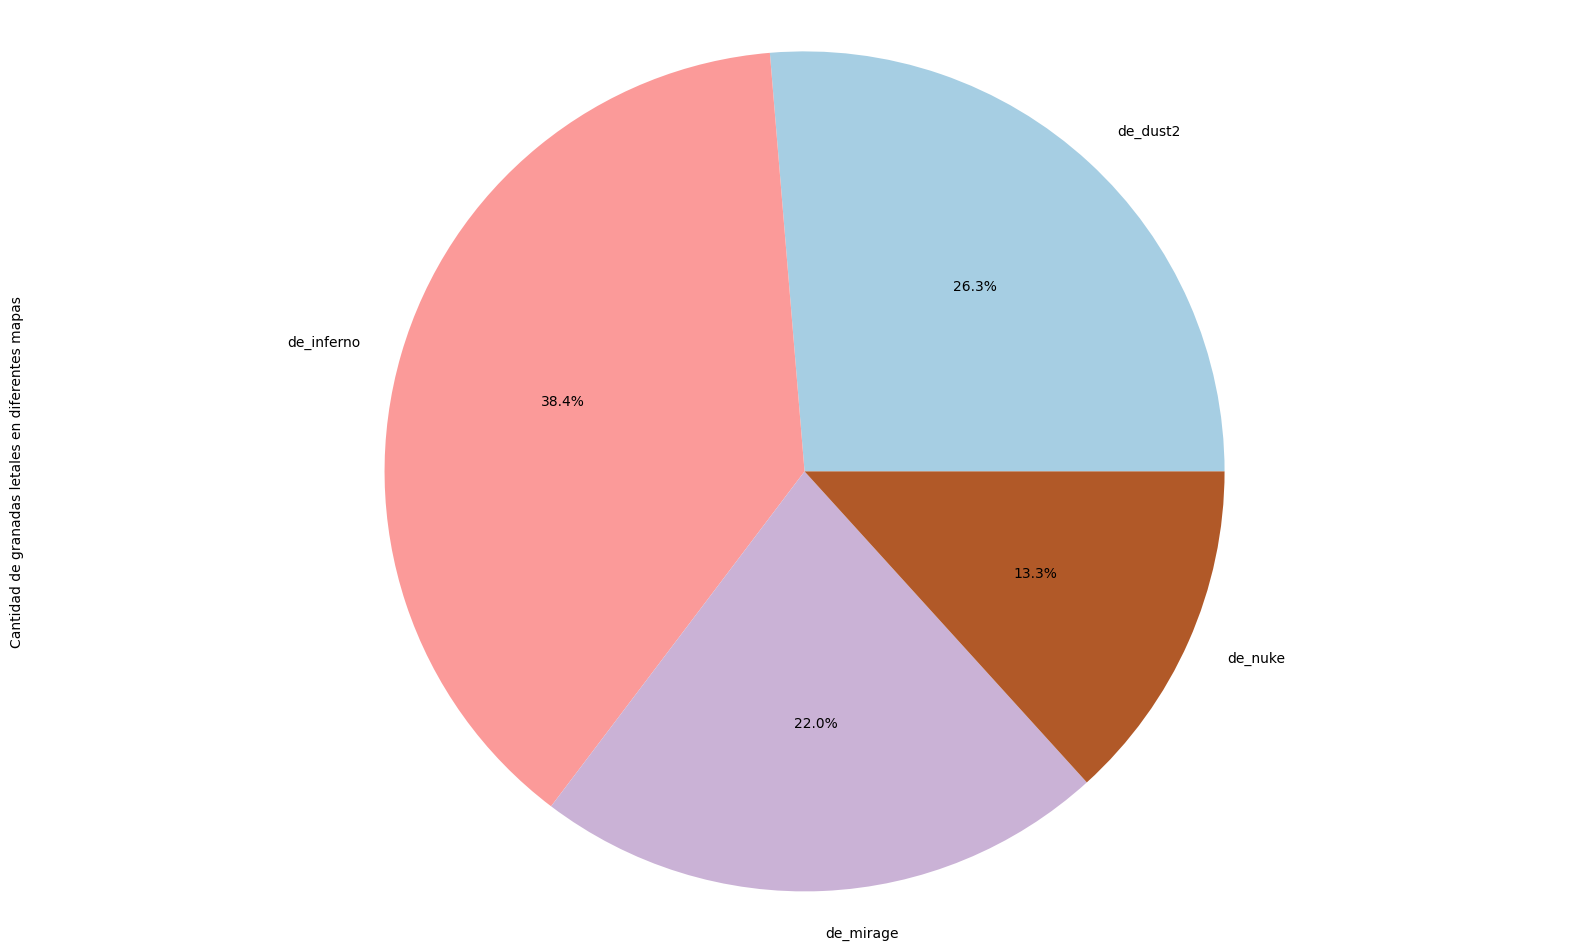

In [ ]:
df.RNonLethalGrenadesThrown.groupby(df.Map).sum().plot(kind='pie', cmap='Paired', autopct='%1.1f%%', figsize=(20,12))
plt.axis('equal')
plt.ylabel('Cantidad de granadas letales en diferentes mapas')
plt.show()

Aqui podemos observar que la mayor cantidad granadas lanzadas que fueron letales para los jugadores enemigos, fueron en el mapa "de_inferno". Asi mismo,"de_nuke" fue el mapa en el cual menos granadas letales fueron lanzadas.

Con los graficos analizados anteriormente, y los datos presentados tambien, podemos deducir como hallazgo que el mapa en el cual los jugadores suelen usar mas granadas es en el mapa de "de_inferno" siendo asi el mapa "favorito" para utilizar este recurso y que el mapa en el cual menos se utilizan granadas es en el mapa "de_nuke", siendo asi el mapa menos "favorito" para utilizar este recurso.

## Cantidad de muertes totales por mapa

In [ ]:
muertePartida = MuertePartida.groupby(df.Map).sum().sort_values(ascending = True)

Text(0.5, 1.0, 'Cantidad de muertes totales por mapa')

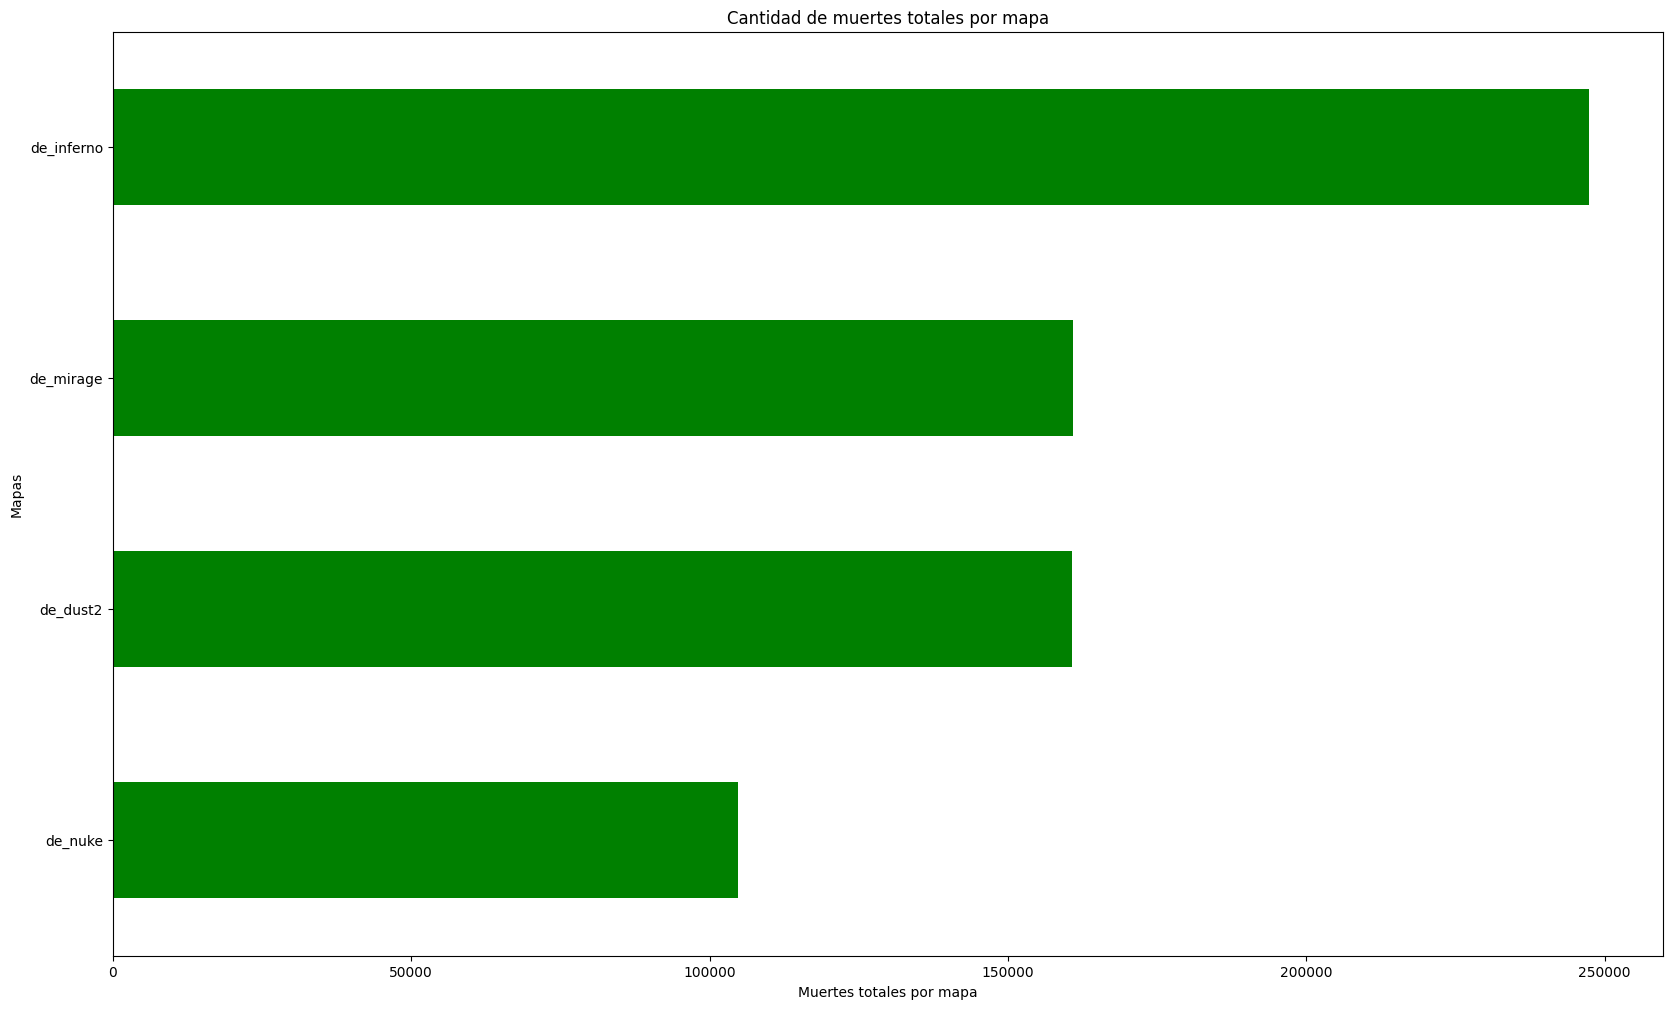

In [ ]:
muertePartida.plot.barh(x = "MAPA",figsize=(20,12), color="green")
plt.ylabel('Mapas')
plt.xlabel('Muertes totales por mapa')
plt.title('Cantidad de muertes totales por mapa')

In [ ]:
MuertePartida.groupby(df.Map).sum().sort_values(ascending = False)

,MatchKills
Map,
de_inferno,247373
de_mirage,160869
de_dust2,160691
de_nuke,104818


En el grafico desarrollado con las variables "MAP" y "MatchKills" se puede ver que el mapa "de_inferno", es donde mas hubieron muertes (247.373), mientras que el mapa "de_nuke" es donde menos hubieron muertes (104.761) de foma general.

## Influencia del costo de equipo por round en las partidas ganadas

In [ ]:
CostoEquipo = df.RoundStartingEquipmentValue.groupby(df.MatchWinner).sum().sort_values(ascending = True)

Text(0.5, 1.0, 'Influencia del costo de equipo por round en las partidas ganadas')

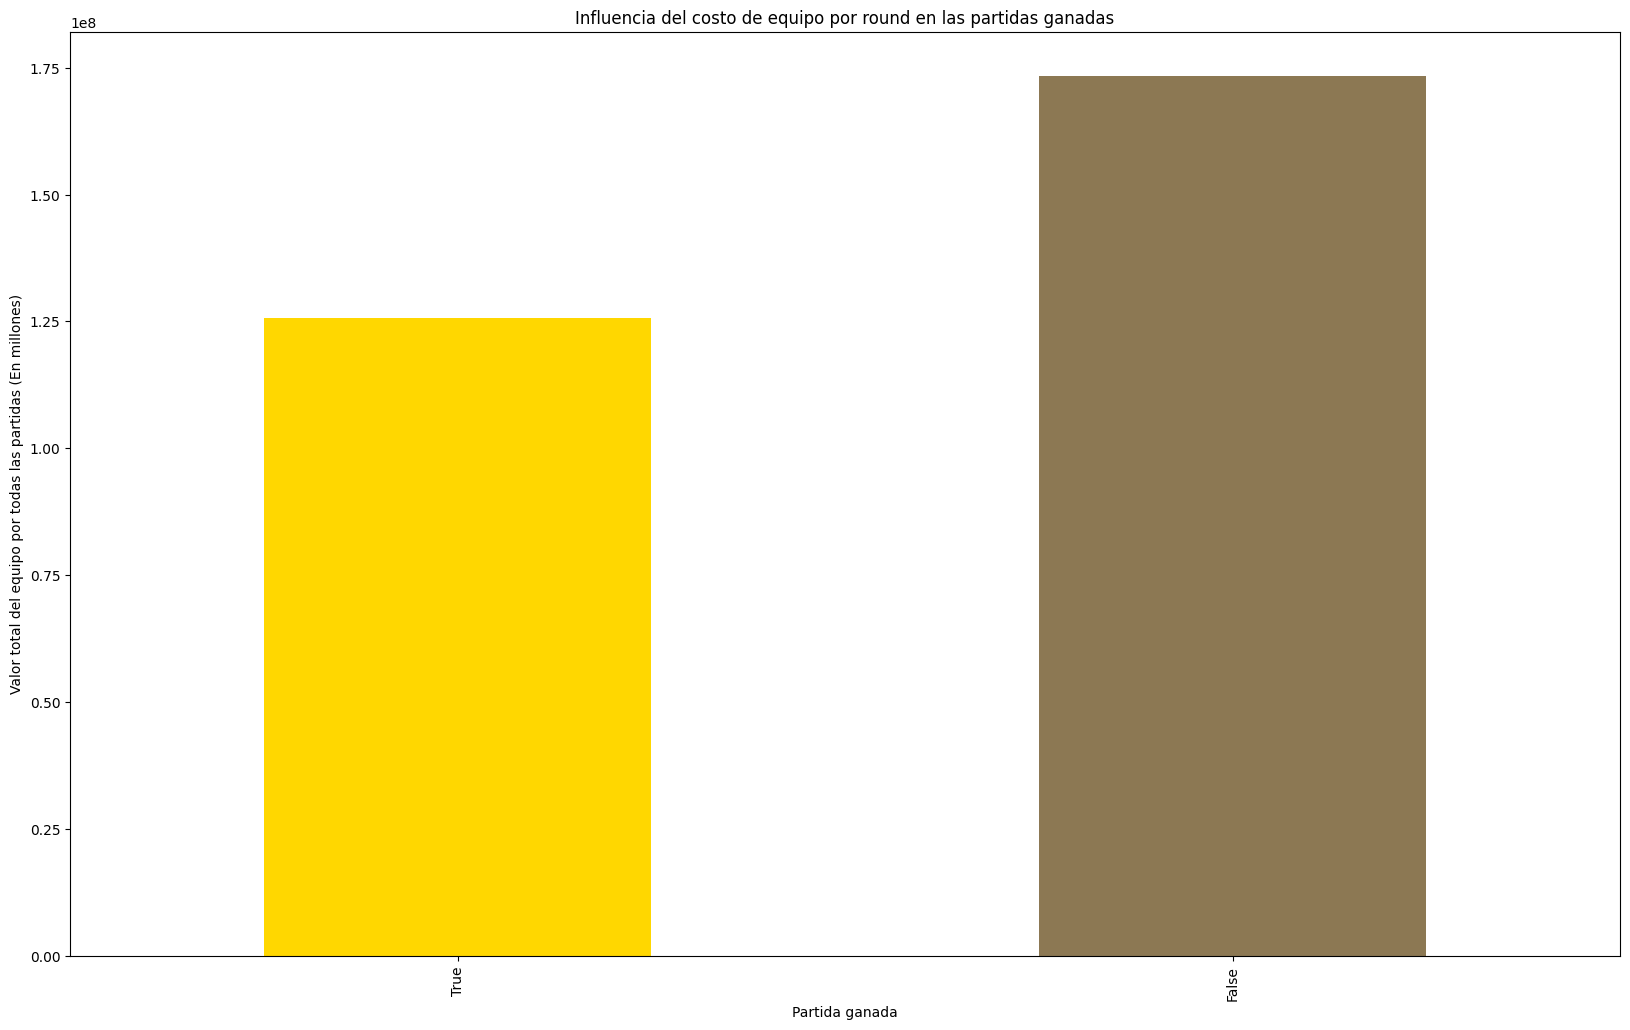

In [ ]:
colores = ['#FFD700','#8C7853']
CostoEquipo.plot.bar(x = "RoundStartingEquipmentValue",figsize=(20,12), color = colores)
plt.ylabel('Valor total del equipo por todas las partidas (En millones)')
plt.xlabel('Partida ganada')
plt.title('Influencia del costo de equipo por round en las partidas ganadas')

In [ ]:
df.RoundStartingEquipmentValue.groupby(df.MatchWinner).sum().sort_values(ascending = True)

,RoundStartingEquipmentValue
MatchWinner,
True,125657500
False,173402000


En el grafico realizado con las variables "RoundStartingEquipmentValue" y "MatchWinner", se puede observar que mientras mas alto sea el costo(sumado) del equipamiento por partida no influye en que esta sea ganada por un equipo, al contrario, mas perdieron.

## Arma mas usada por los jugadores (En porcentaje)

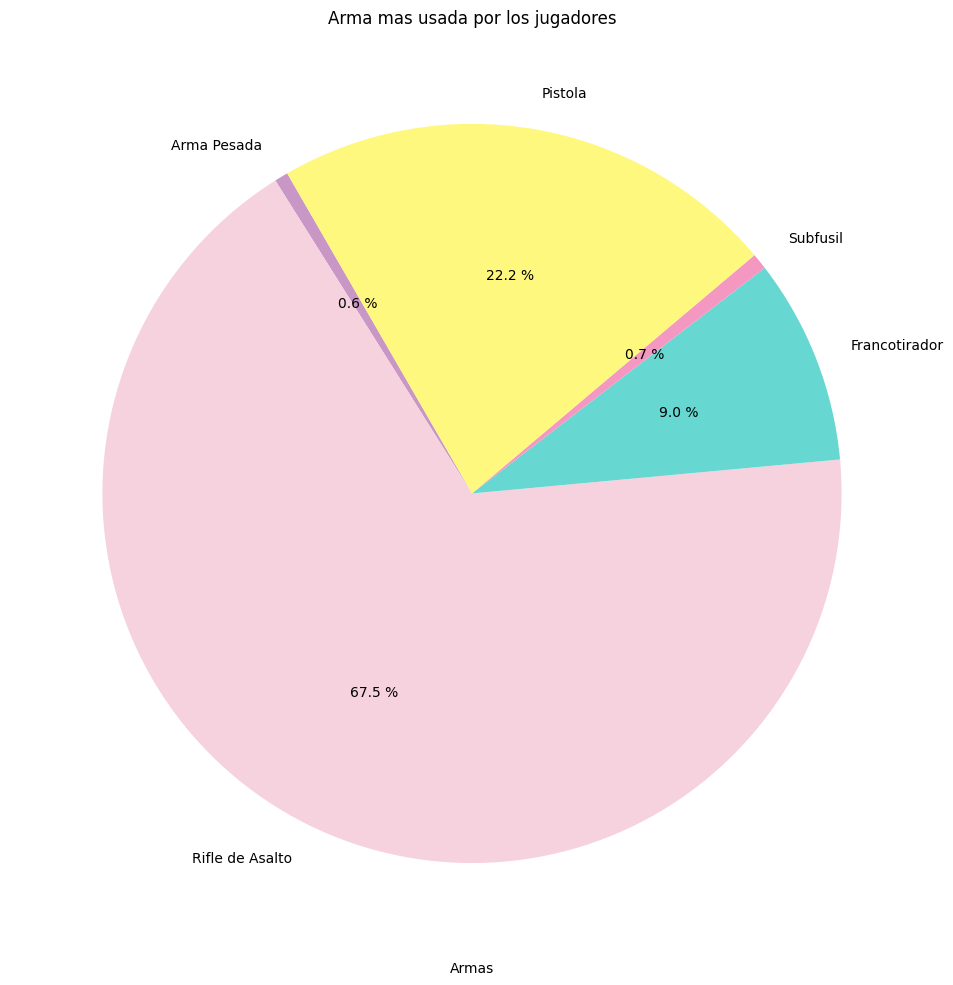

In [ ]:
Heavy = df.PrimaryHeavy.sum()
Asalto = df.PrimaryAssaultRifle.sum()
Sniper = df.PrimarySniperRifle.sum()

SMG = df.PrimarySMG.sum()
Pistola = df.PrimaryPistol.sum()

Armas = [Heavy, Asalto, Sniper, SMG, Pistola]

nombreArmas = ["Arma Pesada","Rifle de Asalto", "Francotirador", "Subfusil", "Pistola"]

colores = ["#C997C6","#F6D1DE","#66D7D1","#F498C2","#FFF87F"]

fig, ax = plt.subplots()
plt.title("Arma mas usada por los jugadores")
plt.pie(Armas, labels=nombreArmas, startangle = 120, autopct="%0.1f %%", colors=colores)
fig.set_size_inches(20, 12)
plt.xlabel('Armas')
plt.show()

Basandonos en el grafico realizado, el arma mas utilizada por los jugadores fue el rifle de asalto con un porcentaje del 67.6%, siendo asi la "Favorita", en segundo lugar la pistola con un 22.1%, tercer lugar Francotirador con un 9.0%, cuarto lugar Subfusil con un 0.7% y quinto el arma pesada con un 0.6% siendo la "menos favorita" por los jugadores.

# Fase 4: Modeling

##Modelos de Regresión

###Matriz de la Correlación

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
plt.rcParams['figure.figsize'] = (16, 9)
plt.style.use('ggplot')

Se genera la Correlación existente actualmente

In [ ]:
correlacion = df.select_dtypes(include=['int64', 'float64']).corr(method='pearson')
correlacion


,Unnamed: 0,InternalTeamId,MatchId,RoundId,RLethalGrenadesThrown,RNonLethalGrenadesThrown,PrimaryAssaultRifle,PrimarySniperRifle,PrimaryHeavy,PrimarySMG,...,RoundKills,RoundAssists,RoundHeadshots,RoundFlankKills,RoundStartingEquipmentValue,TeamStartingEquipmentValue,MatchKills,MatchFlankKills,MatchAssists,MatchHeadshots
Unnamed: 0,1.000000,0.000095,0.999979,0.003375,0.002911,-0.009307,-0.027305,0.043187,0.003781,0.017790,...,0.003284,0.003202,-0.023346,0.005116,0.013323,0.014461,0.009537,0.018839,0.013544,-0.051163
InternalTeamId,0.000095,1.000000,0.000027,-0.000008,0.039136,-0.005408,0.001750,0.042205,0.006337,0.004186,...,0.033085,0.019489,0.006104,0.020169,0.067674,0.073339,0.109532,0.169996,0.112188,0.008841
MatchId,0.999979,0.000027,1.000000,0.001476,0.003009,-0.009234,-0.027313,0.043119,0.003769,0.017847,...,0.003271,0.003197,-0.023296,0.005110,0.013234,0.014364,0.008026,0.017832,0.012419,-0.052360
RoundId,0.003375,-0.000008,0.001476,1.000000,0.065327,0.073314,0.085892,0.026291,-0.003975,-0.029860,...,0.009134,-0.002503,-0.003344,0.010332,0.117606,0.127420,0.807501,0.509277,0.588535,0.688221
RLethalGrenadesThrown,0.002911,0.039136,0.003009,0.065327,1.000000,0.382635,0.326426,-0.018635,-0.023267,0.003408,...,0.162721,0.093738,0.080361,0.073273,0.438817,0.466507,0.110577,0.086692,0.106277,0.092965
RNonLethalGrenadesThrown,-0.009307,-0.005408,-0.009234,0.073314,0.382635,1.000000,0.339062,-0.023421,-0.027057,-0.026666,...,0.148663,0.021319,0.100812,0.054749,0.368180,0.403791,0.099642,0.063542,0.073994,0.092548
PrimaryAssaultRifle,-0.027305,0.001750,-0.027313,0.085892,0.326426,0.339062,1.000000,-0.440642,-0.108901,-0.119824,...,0.127903,0.065941,0.119863,0.063766,0.518780,0.627534,0.095224,0.087460,0.103451,0.142642
PrimarySniperRifle,0.043187,0.042205,0.043119,0.026291,-0.018635,-0.023421,-0.440642,1.000000,-0.024840,-0.026602,...,0.072187,-0.030621,-0.083883,0.004260,0.334221,0.199256,0.069314,0.001269,-0.016344,-0.057624
PrimaryHeavy,0.003781,0.006337,0.003769,-0.003975,-0.023267,-0.027057,-0.108901,-0.024840,1.000000,-0.005862,...,0.001692,0.002628,-0.002897,0.008143,-0.037131,-0.022217,-0.009765,-0.000579,-0.002852,-0.004694
PrimarySMG,0.017790,0.004186,0.017847,-0.029860,0.003408,-0.026666,-0.119824,-0.026602,-0.005862,1.000000,...,0.018592,0.012162,0.012835,0.001398,-0.025325,-0.013120,-0.021469,-0.013826,-0.010295,-0.016383


Función para convertir una matriz de correlación de pandas en formato tidy.
Los datos en Tidy se encuentran ordenados, ademas tienen una estructura que facilita el trabajo; son sencillos de manipular, modelar y visualizar.

In [ ]:
def tidy_corr_matrix(corr_mat):

    corr_mat = corr_mat.stack().reset_index()
    corr_mat.columns = ['variable_1','variable_2','r']
    corr_mat = corr_mat.loc[corr_mat['variable_1'] != corr_mat['variable_2'], :]
    corr_mat['abs_r'] = np.abs(corr_mat['r'])
    corr_mat = corr_mat.sort_values('abs_r', ascending=False)

    return(corr_mat)

tidy_corr_matrix(correlacion).head(10)

,variable_1,variable_2,r,abs_r
2,Unnamed: 0,MatchId,0.999979,0.999979
42,MatchId,Unnamed: 0,0.999979,0.999979
351,TeamStartingEquipmentValue,RoundStartingEquipmentValue,0.922943,0.922943
331,RoundStartingEquipmentValue,TeamStartingEquipmentValue,0.922943,0.922943
437,MatchHeadshots,MatchKills,0.831450,0.831450
377,MatchKills,MatchHeadshots,0.831450,0.831450
346,TeamStartingEquipmentValue,PrimaryPistol,-0.828608,0.828608
226,PrimaryPistol,TeamStartingEquipmentValue,-0.828608,0.828608
360,MatchKills,RoundId,0.807501,0.807501
80,RoundId,MatchKills,0.807501,0.807501


Se genera matriz de correlación

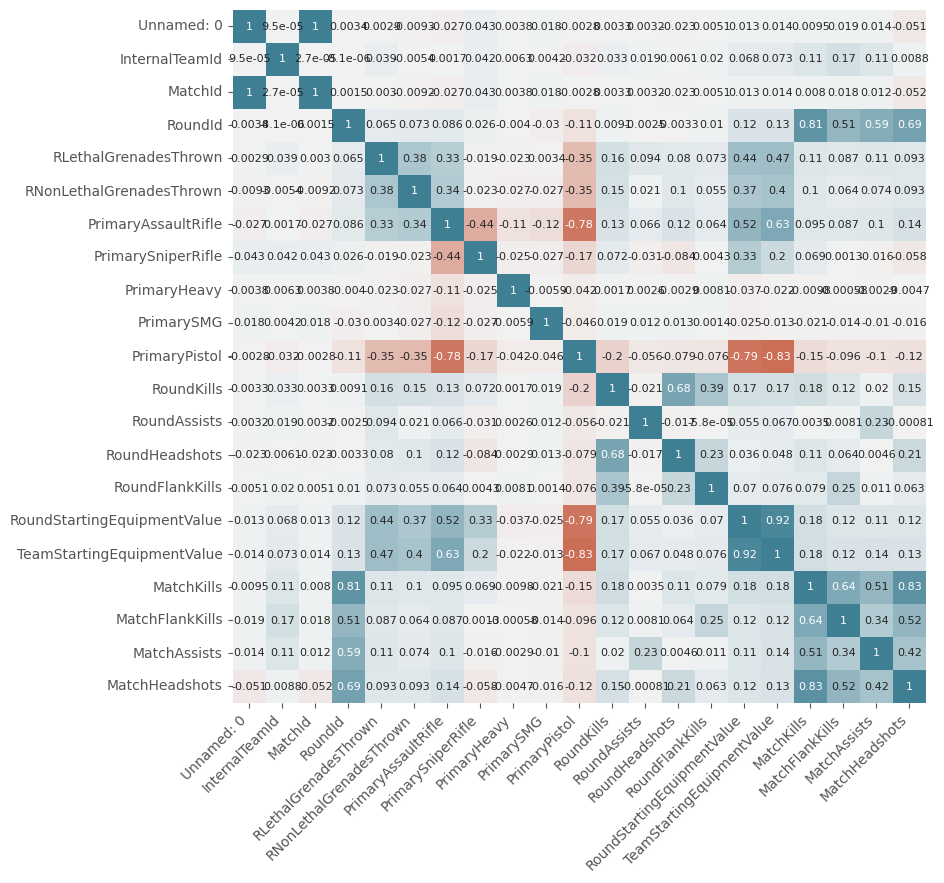

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 9))

sns.heatmap(
    correlacion,
    annot     = True,
    cbar      = False,
    annot_kws = {"size": 8},
    vmin      = -1,
    vmax      = 1,
    center    = 0,
    cmap      = sns.diverging_palette(20, 220, n=200),
    square    = True,
    ax        = ax
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation = 45,
    horizontalalignment = 'right',
)

ax.tick_params(labelsize = 10)

En la matriz de correlación conoceremos la variables que tienen los siguientes criterios:
- Entre 0 y 0,10 -> Correlación inexistente
- Entre 0,10 y 0,29 -> Correlación debil
- Entre 0,30 y 0,50 -> Correlación moderada
- Entre 0,50 y 1,00 -> Correlación fuerte

###Algoritmo Lineal 1

Se definen las variables X e Y, para su uso en la definicion de R2

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size = 0.30, shuffle = False)

import pandas as pd
from sklearn import linear_model
import statsmodels.api as sm

X = df[['MatchHeadshots', 'MatchAssists', 'RoundStartingEquipmentValue', 'RoundHeadshots', 'RoundAssists', 'RoundKills', 'PrimaryPistol','PrimarySMG',
        'PrimaryHeavy','PrimarySniperRifle','PrimaryAssaultRifle' ,'RNonLethalGrenadesThrown' ,
        'RLethalGrenadesThrown']]
y = df['MatchKills']

X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y.values.reshape(-1,1),
                                        train_size   = 0.7,
                                        random_state = 2022,
                                        shuffle      = True
                                    )

MODELO COMPLETO

Modelo OLS completo con las variables Cuantitativas existentes en DataSet

In [ ]:
import statsmodels.formula.api as smf
datos_train = pd.DataFrame(np.hstack((X_train, y_train)),
                           columns=['MatchHeadshots', 'MatchAssists', 'RoundStartingEquipmentValue',
                                    'RoundHeadshots', 'RoundAssists', 'RoundKills','PrimaryPistol','PrimarySMG','PrimaryHeavy',
                                    'PrimarySniperRifle','PrimaryAssaultRifle' ,
                                    'RNonLethalGrenadesThrown' ,'RLethalGrenadesThrown' ,'MatchKills'])
modelo = smf.ols(formula = 'MatchKills ~ MatchHeadshots + MatchAssists + RoundStartingEquipmentValue + RoundHeadshots  + RoundAssists + RoundKills + PrimaryPistol + PrimarySMG + PrimaryHeavy + PrimarySniperRifle + PrimaryAssaultRifle + RNonLethalGrenadesThrown + RLethalGrenadesThrown', data = datos_train)
modelo = modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:             MatchKills   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.754
Method:                 Least Squares   F-statistic:                 1.416e+04
Date:                Fri, 04 Jul 2025   Prob (F-statistic):               0.00
Time:                        00:53:40   Log-Likelihood:            -1.4071e+05
No. Observations:               55409   AIC:                         2.815e+05
Df Residuals:                   55396   BIC:                         2.816e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

Mientras el R2 (R-Squared) mas cercano este a 1, la predicción es mas acertada.
Se observa en el OLS que El R2 es de 0.754, siendo un modelo totalmente predictivo.

MODELO CON SELECCIÓN DE VARIABLES(MATRIZ DE CORRELACIÓN)

Modelo OLS con selección de variables con alta correlación.

In [ ]:
modelo2 = smf.ols(formula = 'MatchKills ~ MatchHeadshots + MatchAssists', data = datos_train)
modelo2 = modelo2.fit()
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:             MatchKills   R-squared:                       0.724
Model:                            OLS   Adj. R-squared:                  0.724
Method:                 Least Squares   F-statistic:                 7.271e+04
Date:                Fri, 04 Jul 2025   Prob (F-statistic):               0.00
Time:                        00:53:40   Log-Likelihood:            -1.4390e+05
No. Observations:               55409   AIC:                         2.878e+05
Df Residuals:                   55406   BIC:                         2.878e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          1.7299      0.023     75.

Mientras el R2 (R-Squared) mas cercano este a 1, la predicción es mas acertada. Se observa en el OLS que El R2 es de 0.724, siendo un modelo totalmente predictivo.

MODELO CON SELECCION DE VARIABLES (VALOR P)

Modelo OLS con selección de variables valor P (que se define como la probabilidad de que un valor estadístico calculado sea posible dada una hipótesis nula cierta)

In [ ]:
modelo3 = smf.ols(formula = 'MatchKills ~ MatchHeadshots + MatchAssists + RoundStartingEquipmentValue + RoundHeadshots  + RoundAssists + RoundKills + PrimaryPistol + PrimarySMG + PrimarySniperRifle + PrimaryAssaultRifle', data = datos_train)
modelo3 = modelo3.fit()
print(modelo3.summary())

                            OLS Regression Results                            
Dep. Variable:             MatchKills   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.754
Method:                 Least Squares   F-statistic:                 1.699e+04
Date:                Fri, 04 Jul 2025   Prob (F-statistic):               0.00
Time:                        00:53:40   Log-Likelihood:            -1.4071e+05
No. Observations:               55409   AIC:                         2.814e+05
Df Residuals:                   55398   BIC:                         2.815e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

Mientras el R2 (R-Squared) mas cercano este a 1, la predicción es mas acertada. Se observa en el OLS que El R2 es de 0.753, siendo un modelo totalmente predictivo.

Diagnóstico errores (residuos) de las predicciones de entrenamiento

In [ ]:
y_train = y_train.flatten()
prediccion_train = modelo2.predict(exog = X_train)
residuos_train   = prediccion_train - y_train

/tmp/ipython-input-89-2776476999.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  axes.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],


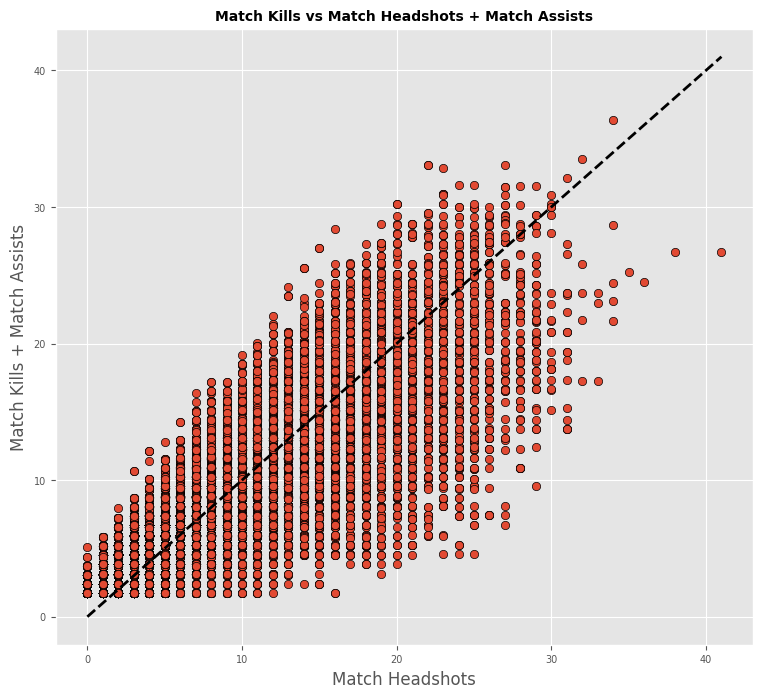

In [ ]:
fig, axes = plt.subplots(figsize=(9, 8))

axes.scatter(y_train, prediccion_train, edgecolors=(0, 0, 0))
axes.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
                'k--', color = 'black', lw=2)
axes.set_title('Match Kills vs Match Headshots + Match Assists', fontsize = 10, fontweight = "bold")
axes.set_xlabel('Match Headshots')
axes.set_ylabel('Match Kills + Match Assists')
axes.tick_params(labelsize = 7)

Como se puede observar en el grafico, podemos ver una linea predictiva negra que va en aumento, podemos ver a traves de los puntos azules que existe cierta igualdad respecto a la prediccion. Ahora nuestro R2 que es de 0.7 aprox. nos dice que ambas tienen una correlacion alta y que tambien son dependientes. Esto demuestra que la variable de head shots influye bastante en los asesinatos y asistencias por partida, pero no lo es del todo, ya que las dos variables mencionadas antes no dependen totalmente de la cantidad de headshots.



###Algoritmo de Arbol de Decisión

In [ ]:
datos = df.select_dtypes(include=['float64', 'int'])

Se inicializa una variable llamada "datos", para luego quitar las variables que no se utilizaran para el modelo predictivo.

In [ ]:
datos = df
datos.rename(columns = {'Unnamed: 0':'id'}, inplace = True)
datos = datos.drop(['Map', 'ScaledTimeAlive', 'TravelledDistance',
       'RLethalGrenadesThrown', 'RNonLethalGrenadesThrown',
       'PrimaryAssaultRifle', 'PrimarySniperRifle', 'PrimaryHeavy',
       'PrimarySMG', 'PrimaryPistol', 'TimeAlive', 'RoundKills', 'RoundAssists', 'RoundHeadshots',
       'RoundStartingEquipmentValue'], axis=1)

Se obtienen las columnas a utilizar

In [ ]:
datos.columns

Index(['RoundWinner', 'MatchWinner', 'Survived', 'AbnormalMatch',
       'FirstKillTime', 'RoundFlankKills', 'TeamStartingEquipmentValue',
       'MatchKills', 'MatchFlankKills', 'MatchAssists', 'MatchHeadshots',
       'accion_efectiva', 'pred'],
      dtype='object')

Se inicializan las variables "X" e "Y"

In [ ]:
X = datos.iloc[:,1:3]
Y = datos.iloc[:,0]

Se realiza el entrenamiento del modelo

In [ ]:
from sklearn.tree import DecisionTreeRegressor

mo2 = DecisionTreeRegressor()
mo2.fit(X, Y)

Yhat = mo2.predict(X)

Se obtiene el mse, mae y R2

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

mse = mean_squared_error(Y, Yhat)
mae = mean_absolute_error(Y, Yhat)
R2 = r2_score(Y, Yhat)

print("MSE: ",mse)
print("MAE: ",mae)
print("R^2: ",R2)

MSE:  10.025776862480653
MAE:  2.3754647349249045
R^2:  0.7387659443219217


- Nuestro MSE(Mean squared error) o error cuadratico medio es: 10.025776862480653, esto nos permite saber el promedio de los errores al cuadrado, es decir, la diferencia entre el estimador y lo que se estima.

- Nuestro MAE(Mean absolute error) o error absoluto medio es: 2.3754647349249045, esto nos proporciona la diferencia entre dos variables continuas.

- Nuestro R2(R cuadrado) o coeficiente de determinación es: 0.7387659443219217, esto quiere decir que mientras mas cercano este a 1 la predicción es mas acertada. Por lo tanto el modelo es totalmente predictivo.

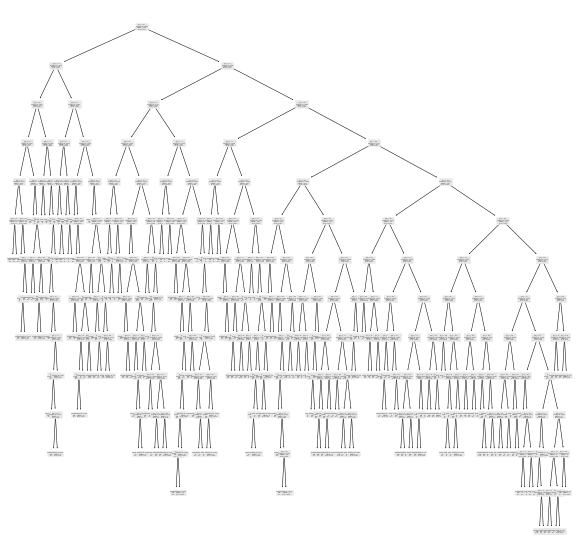

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree
plt.subplots(1,1,figsize=(10,10))
_= tree.plot_tree(mo2)

Como se aprecia en la imagen, se genera el árbol totalmente en bruto, sin entrenar, este, nos muestra una clara tendencia a Falsa (Camino derecho).
Una vez obtenido este árbol, los datos se deben entrenar para poder obtener la profundidad y el número mínimo de muestras requeridas, y así poder generar nuestro modelo de árbol ganador.


Se define la utilización del 80% ddel total del DataSet

In [ ]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X,Y,test_size=0.2)

Se define la profundidad del arbol ganador (max_depth) y el numero mínimo de muestras requeridas (min_sample_split) para la división total de los nodos internos.

In [ ]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np
from sklearn.model_selection import GridSearchCV

model = DecisionTreeRegressor()
params = {"max_depth": np.arange(3,6),          # [3,4,5]
          "min_samples_split": np.arange(2,5)}  # [2,3,4]
grid = GridSearchCV(estimator=model, param_grid=params,cv=10)
grid.fit(Xtrain, Ytrain)

GridSearchCV(cv=10, estimator=DecisionTreeRegressor(),
             param_grid={'max_depth': array([3, 4, 5]),
                         'min_samples_split': array([2, 3, 4])})

Se fija una prueba con una profundidad entre 3 y 6.
Se fija la misma prueba con un numero minimo de muestras requeridas entre 2 y 5.

Se obtiene el score, para saber que tan buena puede ser la predicción y los mejores parametros.

In [ ]:
print(grid.best_score_)
print(grid.best_params_)

0.1616144889153904
{'max_depth': np.int64(3), 'min_samples_split': np.int64(2)}


Los mejores parametros a utilizar son:
 - Profundidad: 5
 - Minimo de muestras requeridos: 2

Se realiza la transformación del score

In [ ]:
acc_decision_tree = round(grid.score(X, Y) * 100, 2)
print(acc_decision_tree,"%")

16.16 %


EL valor obtenido nos muestra o nos da a entender que el modelo es totalmente predictivo.

In [ ]:
pd.DataFrame(grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.013234,0.000895,0.002292,0.000156,3,2,"{'max_depth': 3, 'min_samples_split': 2}",0.693251,0.682469,0.688876,0.711999,0.691603,0.690278,0.693823,0.700257,0.680486,0.690295,0.692334,0.008433,7
1,0.012886,0.000509,0.002223,0.000127,3,3,"{'max_depth': 3, 'min_samples_split': 3}",0.693251,0.682469,0.688876,0.711999,0.691603,0.690278,0.693823,0.700257,0.680486,0.690295,0.692334,0.008433,7
2,0.013269,0.000953,0.002319,0.000070,3,4,"{'max_depth': 3, 'min_samples_split': 4}",0.693251,0.682469,0.688876,0.711999,0.691603,0.690278,0.693823,0.700257,0.680486,0.690295,0.692334,0.008433,7
3,0.015999,0.003166,0.002498,0.000322,4,2,"{'max_depth': 4, 'min_samples_split': 2}",0.718253,0.706211,0.709811,0.735649,0.712337,0.713767,0.717615,0.724120,0.703739,0.713087,0.715459,0.008764,4
4,0.015105,0.001675,0.002349,0.000090,4,3,"{'max_depth': 4, 'min_samples_split': 3}",0.718253,0.706211,0.709811,0.735649,0.712337,0.713767,0.717615,0.724120,0.703739,0.713087,0.715459,0.008764,4
5,0.015041,0.001038,0.002375,0.000047,4,4,"{'max_depth': 4, 'min_samples_split': 4}",0.718253,0.706211,0.709811,0.735649,0.712337,0.713767,0.717615,0.724120,0.703739,0.713087,0.715459,0.008764,4
6,0.016789,0.001458,0.002509,0.000267,5,2,"{'max_depth': 5, 'min_samples_split': 2}",0.732715,0.719963,0.721024,0.746853,0.726266,0.725775,0.729033,0.735099,0.717514,0.725851,0.728009,0.008154,1
7,0.016339,0.000219,0.002471,0.000065,5,3,"{'max_depth': 5, 'min_samples_split': 3}",0.732715,0.719963,0.721024,0.746853,0.726266,0.725775,0.729033,0.735099,0.717514,0.725851,0.728009,0.008154,1
8,0.018001,0.003378,0.002588,0.000291,5,4,"{'max_depth': 5, 'min_samples_split': 4}",0.732715,0.719963,0.721024,0.746853,0.726266,0.725775,0.729033,0.735099,0.717514,0.725851,0.728009,0.008154,1


La tabla anterior nos muestra que tan fiable es hacer el arbol con otras profundidades y minimo de muestras requeridas.

Se genera y visualiza el arbol ganador.

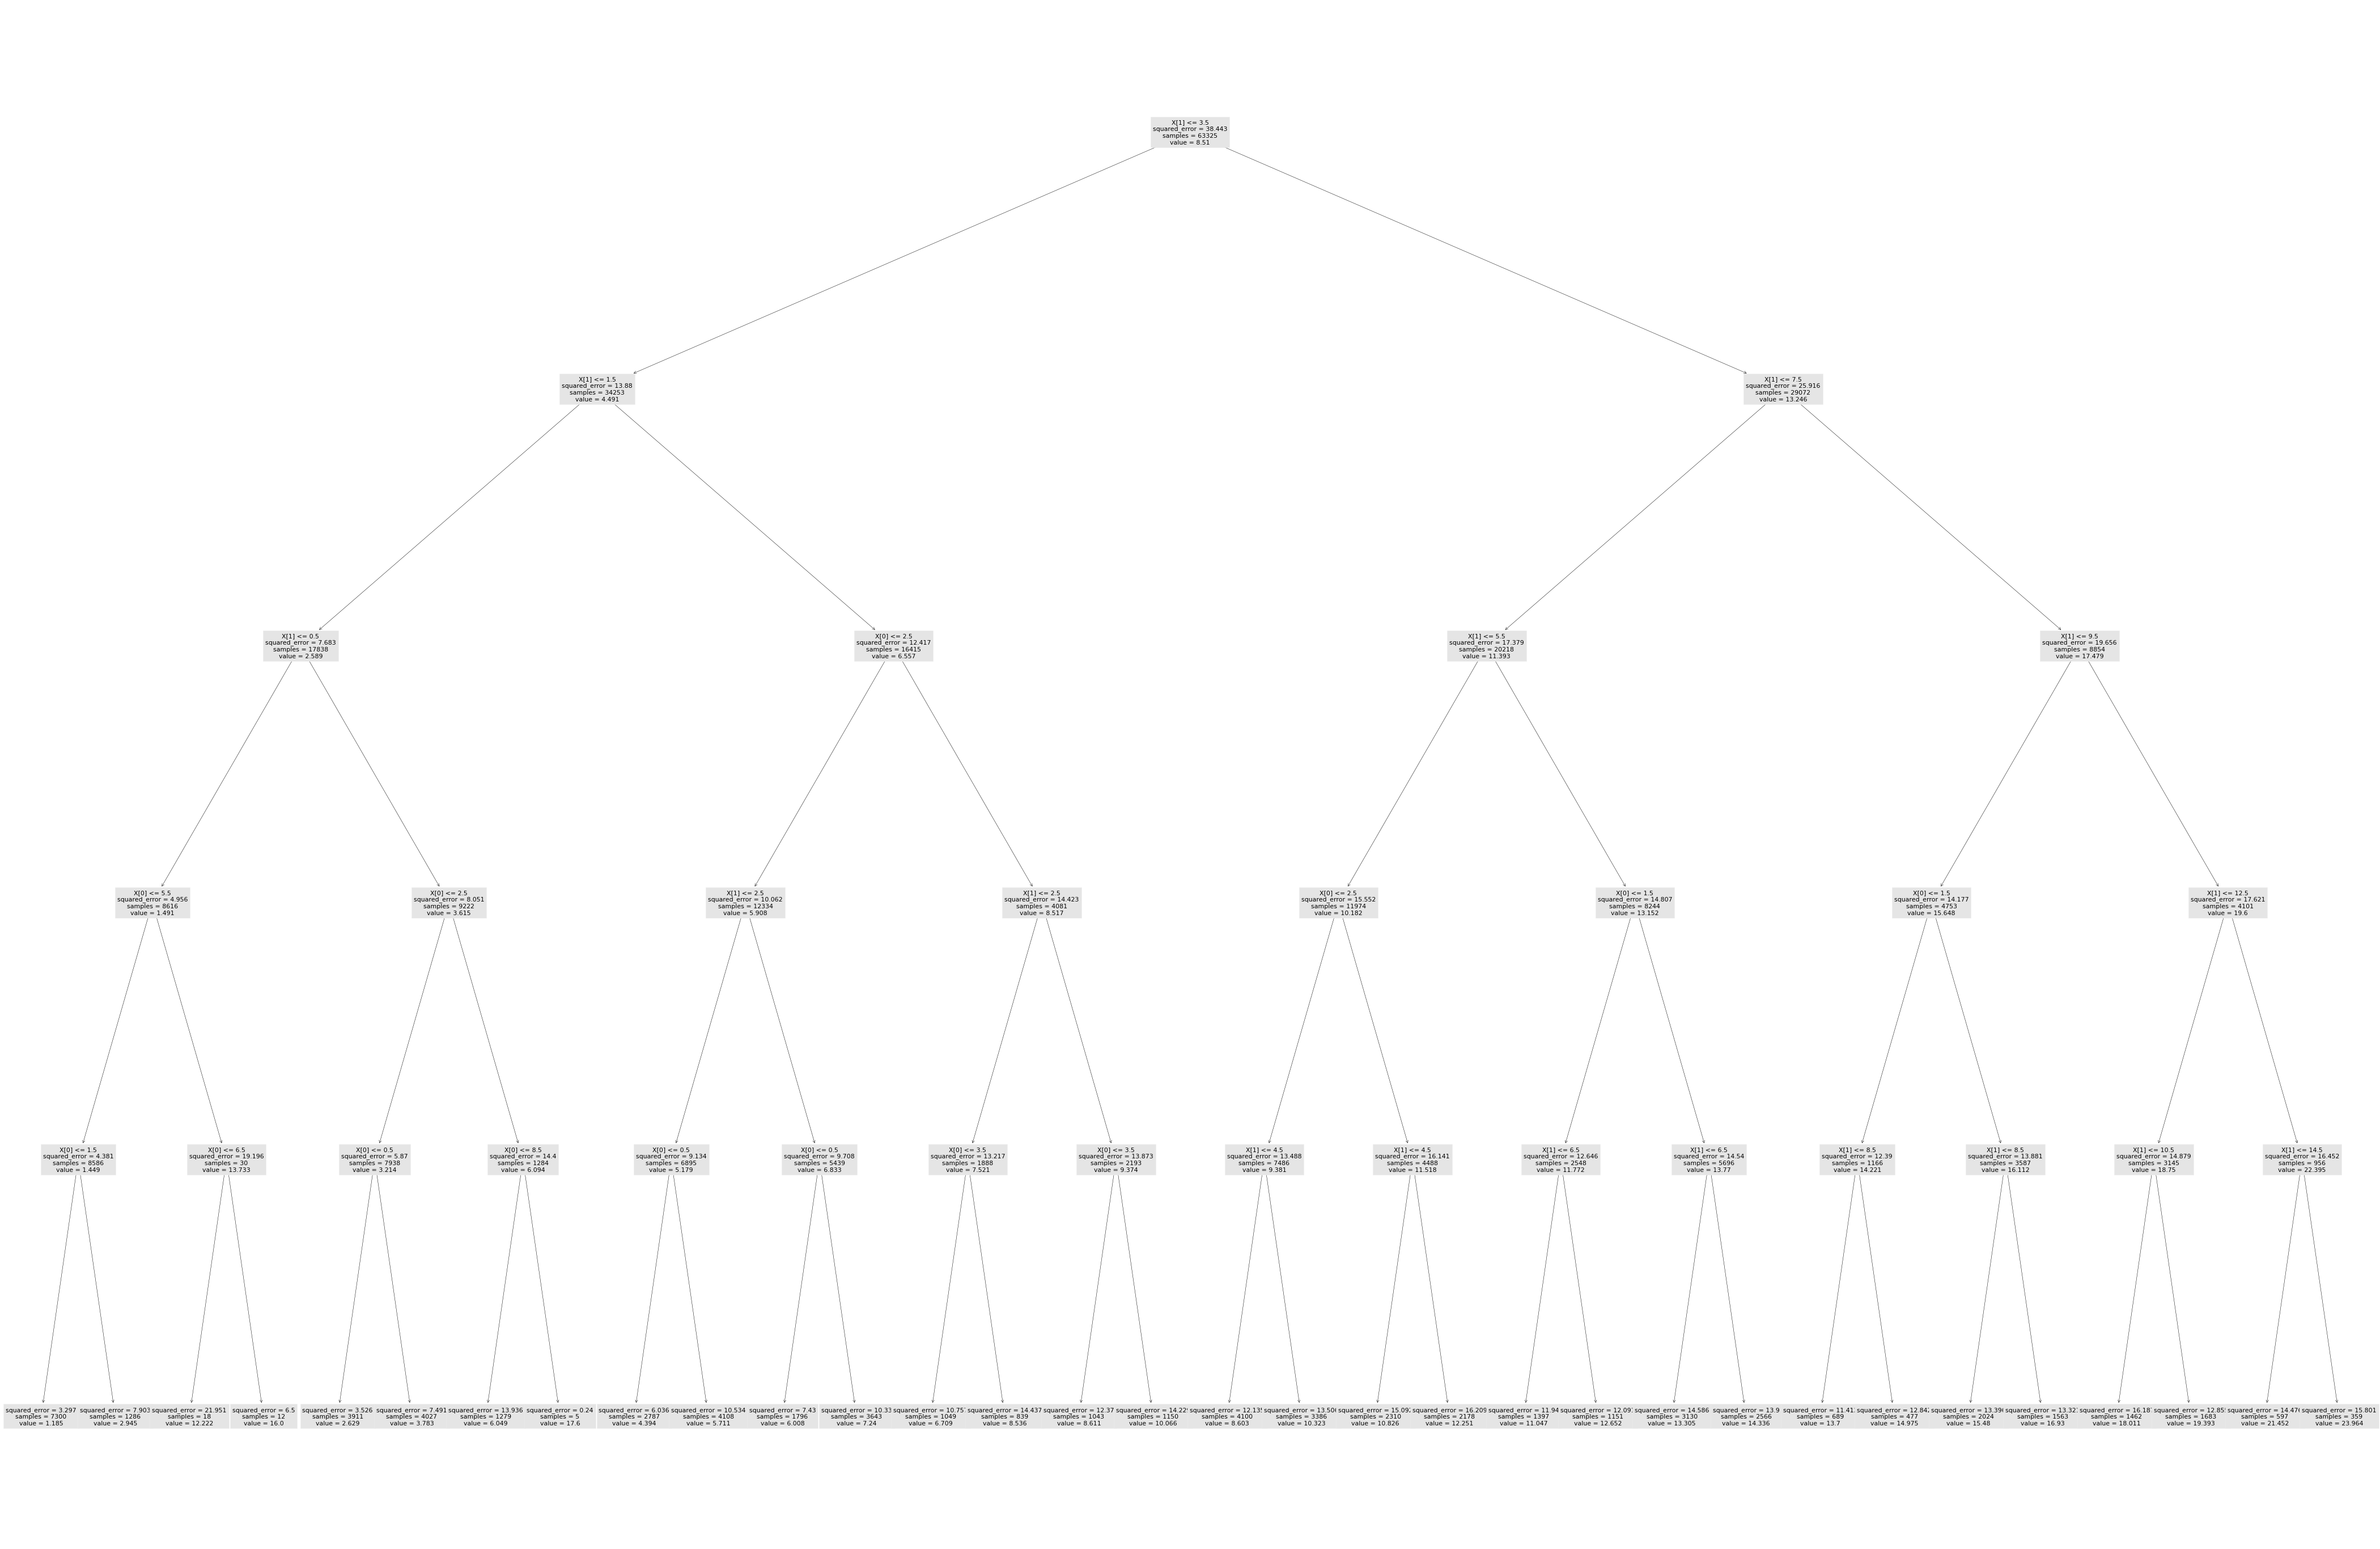

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree
plt.subplots(1,1,figsize=(75,50))
_= tree.plot_tree(grid.best_estimator_, max_depth=5, fontsize=11)

Como se ve en el nodo mas alto, el numero de muestras es de 63.325, ya que solo se uso un 80% del DataSet para su analisis.

- X[0] = MatchAssists
- X[1] = MatchHeadshots

Se crea una variable con la respectiva función de predicción.

In [ ]:
y_pred = grid.predict(X)

Se agrega una columna al DataSet, para realizar comparación en cuanto a la predicción

In [ ]:
df['pred'] = y_pred

Se genera una muestra con 10 datos.

In [ ]:
df.sample(10)[['MatchAssists','MatchHeadshots','pred']]

,MatchAssists,MatchHeadshots,pred
62125,1,9,14.974843
79055,5,11,19.392751
78859,0,1,2.629251
71260,0,1,2.629251
27065,1,5,10.323095
74602,1,0,1.185068
26558,2,6,13.305112
52701,1,2,5.710808
30146,3,13,21.452261
30143,6,5,12.251148


En la tabla contamos con las columnas MatchAssists, MatchHeadshots y pred (predicción), para saber que esta es correcta debemos ir al arbol ganador y seguir el camino correspondiente, respetando las condiciones que este nos entrega (camino hacia la izquierda es Verdadero o True, hacia la derecha es Falso o False, llegando asi al nodo final, el cual cuenta con un value que en caso de predecirlo correctamente deberia ser el mismo, aproximado, en caso de no predecir el dato, este deberia mostrar un numero erroneo.

CONCLUSIÓN

Se desarrollo un arbol de desición de tipo regresión, obteniendo un primer modelo "En bruto", el cual fue entrenado y generado nuevamente obteniendo menos profundidad pero mas certeza al momento de predecir datos. Este arbol entrenado nos deja en constancia su alto porcentaje de predicción, el cual es un 73.12%, lo que es alto. Su asertividad en la predicción queda demostrado en la tabla muestra generada al final del algoritmo, el cual al seguir el camino correspondiente en el arbol, llega al value presentado por la columna (pred).

###Formulario Interactivo

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import numpy as np
import pandas as pd



# Variables numéricas: rangos aproximados
numeric_variables = {
    'MatchHeadshots': (0, 50, 1),
    'MatchAssists': (0, 30, 1),
    'RoundStartingEquipmentValue': (0, 10000, 100),
    'RoundHeadshots': (0, 50, 1),
    'RoundAssists': (0, 30, 1),
    'RoundKills': (0, 50, 1),
    'RNonLethalGrenadesThrown': (0, 6, 1),      # actualizado
    'RLethalGrenadesThrown': (0, 4, 1)          # actualizado
}

# Variables categóricas (strings)
categorical_variables = [
    'PrimaryPistol',
    'PrimarySMG',
    'PrimaryHeavy',
    'PrimarySniperRifle',
    'PrimaryAssaultRifle'
]

categorical_options = ['Yes', 'No']  # o ajusta aquí a ['1', '0'] si corresponde

widgets_dict = {}

# Crear widgets para numéricas
for var, (min_, max_, step) in numeric_variables.items():
    widgets_dict[var] = widgets.IntSlider(
        value=0, min=min_, max=max_, step=step, description=var, continuous_update=False
    )

# Crear widgets para categóricas
for var in categorical_variables:
    widgets_dict[var] = widgets.Dropdown(
        options=categorical_options,
        value=categorical_options[1],
        description=var
    )

predict_button = widgets.Button(description="Predecir MatchKills", button_style='success')
output = widgets.Output()

def on_predict_clicked(b):
    input_values = []
    for var in list(numeric_variables.keys()) + categorical_variables:
        val = widgets_dict[var].value
        # Si es categórica y necesita convertirse a 0/1:
        if var in categorical_variables:
            val = 1 if val == 'Yes' else 0
        input_values.append(val)
    input_data = np.array([input_values])
    input_df = pd.DataFrame(input_data, columns=list(numeric_variables.keys()) + categorical_variables)
    pred = modelo3.predict(input_df)[0]
    with output:
        output.clear_output()
        print(f"🔷 Predicción de MatchKills: {pred:.2f}")

predict_button.on_click(on_predict_clicked)

form_items = [widgets_dict[var] for var in numeric_variables] + \
             [widgets_dict[var] for var in categorical_variables]

display(widgets.VBox(form_items + [predict_button, output]))


##Modelos de Clasificación

###SVM (Máquinas de vectores soporte) (SVC)

In [23]:
import pandas as pd

# Cargar el CSV
df = pd.read_csv("Anexo ET_demo_round_traces_2022 (1).csv", sep=";")

# Verificar que cargó bien
df.head()



/tmp/ipython-input-23-1572608078.py:4: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Anexo ET_demo_round_traces_2022 (1).csv", sep=";")


,Unnamed: 0,Map,Team,InternalTeamId,MatchId,RoundId,RoundWinner,MatchWinner,Survived,AbnormalMatch,...,RoundKills,RoundAssists,RoundHeadshots,RoundFlankKills,RoundStartingEquipmentValue,TeamStartingEquipmentValue,MatchKills,MatchFlankKills,MatchAssists,MatchHeadshots
0,600,de_inferno,Terrorist,1,4,1,False,True,False,False,...,0,0,0,0,750,4400,0,0,0,0
1,601,de_inferno,Terrorist,1,4,1,False,True,False,False,...,0,0,0,0,800,4400,0,0,0,0
2,602,de_inferno,Terrorist,1,4,1,False,True,False,False,...,0,0,0,0,1000,4400,0,0,0,0
3,603,de_inferno,Terrorist,1,4,1,False,True,False,False,...,0,0,0,0,850,4400,0,0,0,0
4,604,de_inferno,Terrorist,1,4,1,False,True,True,False,...,0,0,0,0,1000,4400,0,0,0,0


Creamos una copia de nuestro DF, para utilizar y poder mover datos sin afectar nuestro trabajo anterior

In [32]:
df[df.isnull().any(axis=1)]

,Unnamed: 0,Map,Team,InternalTeamId,MatchId,RoundId,RoundWinner,MatchWinner,Survived,AbnormalMatch,...,RoundKills,RoundAssists,RoundHeadshots,RoundFlankKills,RoundStartingEquipmentValue,TeamStartingEquipmentValue,MatchKills,MatchFlankKills,MatchAssists,MatchHeadshots


In [25]:
# Revisar filas con cualquier NaN
filas_nulas = df[df.isnull().any(axis=1)]
print("Filas con valores nulos:")
print(filas_nulas)

# Reemplazar valores en 'Team'
for idx in filas_nulas.index:
    if pd.isnull(df.at[idx, 'Team']):
        # aquí puedes decidir qué poner: Terrorist o CounterTerrorist
        df.at[idx, 'Team'] = 'Terrorist'  # o 'CounterTerrorist'

# Reemplazar valores en 'MatchWinner'
for idx in filas_nulas.index:
    if pd.isnull(df.at[idx, 'MatchWinner']):
        df.at[idx, 'MatchWinner'] = True

# Verificar que no queden NaN
print("\nValores nulos restantes por columna:")
print(df.isnull().sum())


Filas con valores nulos:
    Unnamed: 0         Map              Team  InternalTeamId  MatchId  \
13         613  de_inferno               NaN               1        4   
27         627  de_inferno               NaN               2        4   
29         629  de_inferno  CounterTerrorist               2        4   

    RoundId RoundWinner MatchWinner  Survived  AbnormalMatch  ... RoundKills  \
13        2        True        True     False          False  ...          0   
27        3       False       False      True          False  ...          1   
29        3      False4         NaN      True          False  ...          0   

   RoundAssists  RoundHeadshots  RoundFlankKills  RoundStartingEquipmentValue  \
13            0               0                0                          300   
27            0               0                0                         3250   
29            0               0                0                         4250   

    TeamStartingEquipmentValue  Matc

Ahora definimos las variables que utilizaremos para este Modelo De CLASIFICACIÓN

In [ ]:
Matriz de Confusión

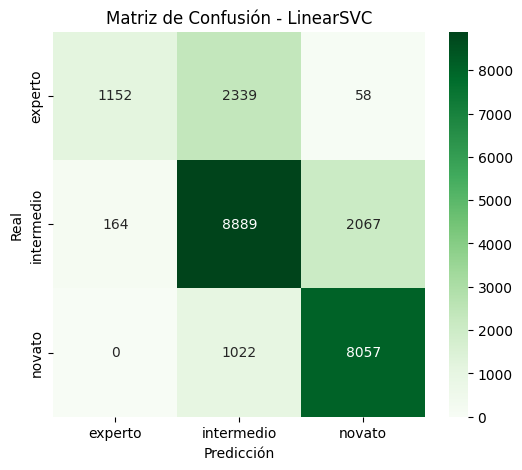

In [46]:
# Predicciones de LinearSVC
y_pred_svm = svm_model.predict(X_test)

# Calcular matriz de confusión
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=svm_model.classes_)

# Graficar
plt.figure(figsize=(6,5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - LinearSVC')
plt.show()


In [39]:
def clasificar_jugador(kills):
    if kills <= 5:
        return "novato"
    elif kills <= 15:
        return "intermedio"
    else:
        return "experto"

df['CategoriaJugador'] = df['MatchKills'].apply(clasificar_jugador)


In [40]:
y = df['CategoriaJugador']


In [27]:
boolean_columns = [
    'PrimaryPistol', 'PrimarySMG', 'PrimaryHeavy',
    'PrimarySniperRifle', 'PrimaryAssaultRifle'
]

for col in boolean_columns:
    X[col] = (
        X[col]
        .fillna('False')
        .astype(str)
        .str.lower()
        .map({'true': 1, 'false': 0})
    )


Las columnas PrimaryXXX tienen valores como texto.
Aquí los convertimos a valores numéricos (1 o 0), que es lo que necesita el modelo para trabajar correctamente.
Esto solo afecta a X, no a df.



In [33]:
X = X.fillna(0)


Dividimos los datos en entrenamiento y los de prueba

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)



Aquí dividimos el dataset en dos partes: 70% para entrenar el modelo (X_train, y_train) y 30% para probar su desempeño (X_test, y_test).
El parámetro stratify=y asegura que las proporciones de clases se mantengan iguales en ambas partes.

In [42]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(max_iter=5000, random_state=42)
svm_model.fit(X_train, y_train)



LinearSVC(max_iter=5000, random_state=42)

Creamos una instancia del modelo SVC de soporte vectorial con un kernel lineal y lo entrenamos con los datos de entrenamiento.
Aquí es donde el modelo aprende a clasificar entre Terrorist y CounterTerrorist.

In [43]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_svm = svm_model.predict(X_test)

print(f"LinearSVC - Accuracy en test: {accuracy_score(y_test, y_pred_svm):.2f}")
print("\nLinearSVC - Reporte de clasificación:\n", classification_report(y_test, y_pred_svm))


LinearSVC - Accuracy en test: 0.76

LinearSVC - Reporte de clasificación:
               precision    recall  f1-score   support

     experto       0.88      0.32      0.47      3549
  intermedio       0.73      0.80      0.76     11120
      novato       0.79      0.89      0.84      9079

    accuracy                           0.76     23748
   macro avg       0.80      0.67      0.69     23748
weighted avg       0.77      0.76      0.75     23748



Hacemos predicciones sobre los datos de prueba y mostramos la precisión (accuracy) junto a métricas detalladas (precision, recall, f1-score) para ambas clases (Terrorist y CounterTerrorist).



###LogisticRegression

In [14]:
def clasificar_jugador(kills):
    if kills <= 5:
        return "novato"
    elif kills <= 15:
        return "intermedio"
    else:
        return "experto"

df['CategoriaJugador'] = df['MatchKills'].apply(clasificar_jugador)

df['CategoriaJugador'].value_counts()


,count
CategoriaJugador,
intermedio,37064
novato,30263
experto,11830


Que hicimos acá?, se creo una columna multiclase la cual nos servirá para nuestro estudio de clasificación mediante este modelo.

Matriz de Confusión

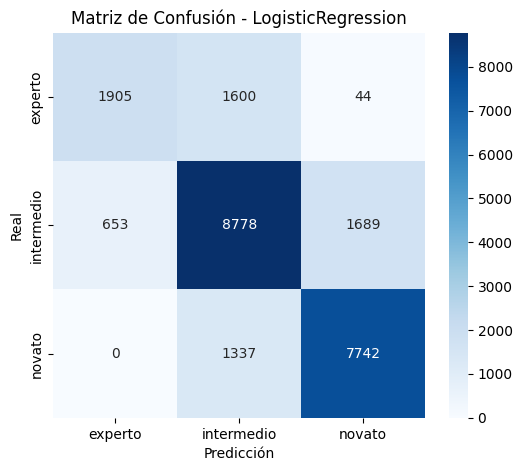

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predicciones de LogisticRegression
y_pred_logreg = logreg_model.predict(X_test)

# Calcular matriz de confusión
cm_logreg = confusion_matrix(y_test, y_pred_logreg, labels=logreg_model.classes_)

# Graficar
plt.figure(figsize=(6,5))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues',
            xticklabels=logreg_model.classes_, yticklabels=logreg_model.classes_)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - LogisticRegression')
plt.show()


Ahora debemos definir nuestra X, Y

In [15]:
X = df[[
    'MatchHeadshots', 'MatchAssists', 'RoundStartingEquipmentValue',
    'RoundHeadshots', 'RoundAssists', 'RoundKills',
    'PrimaryPistol', 'PrimarySMG', 'PrimaryHeavy',
    'PrimarySniperRifle', 'PrimaryAssaultRifle',
    'RNonLethalGrenadesThrown', 'RLethalGrenadesThrown'
]].copy()

y = df['CategoriaJugador']


In [16]:
boolean_columns = [
    'PrimaryPistol', 'PrimarySMG', 'PrimaryHeavy',
    'PrimarySniperRifle', 'PrimaryAssaultRifle'
]

for col in boolean_columns:
    X[col] = (
        X[col]
        .fillna('False')
        .astype(str)
        .str.lower()
        .map({'true': 1, 'false': 0})
    )

X = X.fillna(0)


Se divide nuestra variable de entrenamiento y de prueba

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


Dividimos en 70% para entrenamiento y 30% para prueba, manteniendo la proporción de clases.

Entrenamos el modelo LogisticRegression

In [18]:
from sklearn.linear_model import LogisticRegression

logreg_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
logreg_model.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

In [19]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = logreg_model.predict(X_test)

print(f"Accuracy en test: {accuracy_score(y_test, y_pred):.2f}")
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))


Accuracy en test: 0.78

Reporte de clasificación:
               precision    recall  f1-score   support

     experto       0.74      0.54      0.62      3549
  intermedio       0.75      0.79      0.77     11120
      novato       0.82      0.85      0.83      9079

    accuracy                           0.78     23748
   macro avg       0.77      0.73      0.74     23748
weighted avg       0.77      0.78      0.77     23748



Calculamos la precisión global y mostramos métricas detalladas para cada categoría.

In [20]:
from sklearn.metrics import classification_report
import pandas as pd

# Calcula el reporte como dict
report_dict = classification_report(y_test, y_pred, output_dict=True)

# Filtra solo las 3 clases (excluyendo accuracy, macro avg, weighted avg)
clases = ['experto', 'intermedio', 'novato']
metricas_df = pd.DataFrame({clase: report_dict[clase] for clase in clases}).T

# Reordena las columnas y redondea
metricas_df = metricas_df[['precision', 'recall', 'f1-score', 'support']].round(2)

# Muestra la tabla
print(metricas_df)


            precision  recall  f1-score  support
experto          0.74    0.54      0.62   3549.0
intermedio       0.75    0.79      0.77  11120.0
novato           0.82    0.85      0.83   9079.0


###SVR

In [ ]:
# BLOQUE 1: Cargar los datos
import pandas as pd


df = pd.read_csv('Anexo ET_demo_round_traces_2022.csv', sep=';')



df.head()


In [ ]:
# BLOQUE 2: Seleccionar columnas (X = características, y = objetivo)

X = df[['MatchHeadshots', 'MatchAssists', 'RoundStartingEquipmentValue', 'RoundHeadshots', 'RoundAssists',
        'RoundKills', 'PrimaryPistol','PrimarySMG','PrimaryHeavy','PrimarySniperRifle','PrimaryAssaultRifle',
        'RNonLethalGrenadesThrown', 'RLethalGrenadesThrown']]

y = df['MatchKills']


In [ ]:
# BLOQUE 4: Escalar variables
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)


In [ ]:
# BLOQUE 5: Entrenar modelo SVR
from sklearn.svm import SVR
import time

inicio = time.time()

modelo_svr = SVR(kernel='rbf', C=1.0, epsilon=0.2)
modelo_svr.fit(X_train_scaled, y_train_scaled.ravel())

fin = time.time()
print(f"⏳ Tiempo de entrenamiento: {fin - inicio:.2f} segundos")


⏳ Tiempo de entrenamiento: 163.22 segundos


In [ ]:
# BLOQUE 6: Predicción
y_pred_scaled = modelo_svr.predict(X_test_scaled)

# Invertir escalado para interpretar resultados reales
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1))
y_test_real = scaler_y.inverse_transform(y_test_scaled)


In [ ]:
# BLOQUE 7: Evaluación
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("🔍 Evaluación del modelo SVR:")
print(f"MAE: {mean_absolute_error(y_test_real, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test_real, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_real, y_pred)):.2f}")
print(f"R² Score: {r2_score(y_test_real, y_pred):.2f}")


🔍 Evaluación del modelo SVR:
MAE: 2.21
MSE: 9.26
RMSE: 3.04
R² Score: 0.76


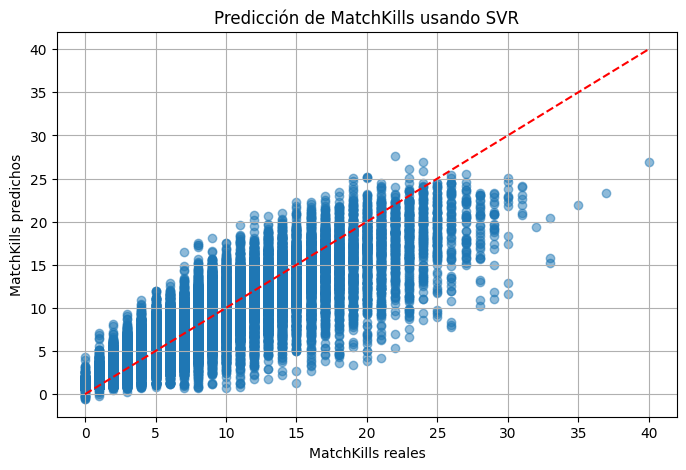

In [ ]:
# BLOQUE 8: Gráfico Real vs. Predicho
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test_real, y_pred, alpha=0.5)
plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--')
plt.xlabel("MatchKills reales")
plt.ylabel("MatchKills predichos")
plt.title("Predicción de MatchKills usando SVR")
plt.grid(True)
plt.show()


El modelo SVR (Support Vector Regressor) mostró un desempeño sólido al predecir la cantidad de eliminaciones (MatchKills) que un jugador realiza durante una partida. El error absoluto medio (MAE) fue de 2.21, lo que indica que, en promedio, las predicciones del modelo se desvían aproximadamente 2.2 eliminaciones respecto al valor real. El error cuadrático medio (MSE) fue de 9.26, y su raíz cuadrada (RMSE) de 3.04, lo cual da una idea de la magnitud del error típico en las predicciones. Finalmente, el coeficiente de determinación R² alcanzó un valor de 0.76, lo que significa que el modelo logra explicar un 76% de la variabilidad en la variable objetivo. En resumen, el modelo SVR proporciona predicciones razonablemente precisas y captura buena parte del comportamiento del sistema, aunque aún existe margen de mejora.

###Formulario Interactivo Utilizando LOGISTICREGRESSION

Porque usamos este modelo para nuestro formulario?

Usamos este formulario debido a que alcanzo casi un 80% de precision en su datos (78%), lo cual lo hace una fuente viable de predecir datos

In [22]:
import ipywidgets as widgets
from IPython.display import display
import pandas as pd

# Variables numéricas y rangos aproximados (ajusta según tus datos reales)
numeric_vars = {
    'MatchHeadshots': (0, 50, 1),
    'MatchAssists': (0, 30, 1),
    'RoundStartingEquipmentValue': (0, 10000, 100),
    'RoundHeadshots': (0, 50, 1),
    'RoundAssists': (0, 30, 1),
    'RoundKills': (0, 50, 1),
    'RNonLethalGrenadesThrown': (0, 6, 1),
    'RLethalGrenadesThrown': (0, 4, 1)
}

boolean_vars = [
    'PrimaryPistol', 'PrimarySMG', 'PrimaryHeavy',
    'PrimarySniperRifle', 'PrimaryAssaultRifle'
]

# Widgets
widgets_dict = {}
for var, (min_, max_, step) in numeric_vars.items():
    widgets_dict[var] = widgets.IntSlider(value=0, min=min_, max=max_, step=step, description=var, continuous_update=False)

for var in boolean_vars:
    widgets_dict[var] = widgets.Dropdown(
        options=['False', 'True'],
        value='False',
        description=var
    )

predict_button = widgets.Button(description="Predecir categoría", button_style='success')
output = widgets.Output()

def on_predict_clicked(b):
    input_data = []
    for var in list(numeric_vars.keys()) + boolean_vars:
        val = widgets_dict[var].value
        if var in boolean_vars:
            val = 1 if val == 'True' else 0
        input_data.append(val)

    input_df = pd.DataFrame([input_data], columns=logreg_model.feature_names_in_)
    pred = logreg_model.predict(input_df)[0]
    with output:
        output.clear_output()
        print(f"🔷 Categoría predicha: {pred}")


predict_button.on_click(on_predict_clicked)

form_items = [widgets_dict[var] for var in numeric_vars] + [widgets_dict[var] for var in boolean_vars]

display(widgets.VBox(form_items + [predict_button, output]))


#Fase 5: Evaluation

##Escogiendo el mejor modelo de Regresión

Esto corresponde a los valores entregados por el modelo de Regresion Lineal

In [ ]:
modelo2 = smf.ols(formula = 'MatchKills ~ MatchHeadshots + MatchAssists', data = datos_train)
modelo2 = modelo2.fit()
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:             MatchKills   R-squared:                       0.724
Model:                            OLS   Adj. R-squared:                  0.724
Method:                 Least Squares   F-statistic:                 7.271e+04
Date:                Fri, 04 Jul 2025   Prob (F-statistic):               0.00
Time:                        00:53:40   Log-Likelihood:            -1.4390e+05
No. Observations:               55409   AIC:                         2.878e+05
Df Residuals:                   55406   BIC:                         2.878e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          1.7299      0.023     75.

Y esto corresponde a lo entregado y entrenado por el algoritmo del arbol de decision

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

mse = mean_squared_error(Y, Yhat)
mae = mean_absolute_error(Y, Yhat)
R2 = r2_score(Y, Yhat)

print("MSE: ",mse)
print("MAE: ",mae)
print("R^2: ",R2)

MSE:  10.025776862480653
MAE:  2.3754647349249045
R^2:  0.7387659443219217


In [47]:
import pandas as pd

resultados = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Árbol de Decisión'],
    'R2': [0.7388, 0.616],
    'MSE': [10.03, 15.2],
    'MAE': [2.38, 3.1]
})

print(resultados)


              Modelo      R2    MSE   MAE
0   Regresión Lineal  0.7388  10.03  2.38
1  Árbol de Decisión  0.6160  15.20  3.10


Tras comparar ambos modelos, la regresión lineal demuestra un mejor desempeño general en la predicción de MatchKills, con un coeficiente de determinación
𝑅
2
R
2
  de 0.7388, superior al
𝑅
2
R
2
  del árbol de decisión (0.616). Esto indica que la regresión lineal explica aproximadamente un 74% de la variabilidad de los datos, mientras que el árbol solo explica alrededor del 62%. Además, la regresión lineal presenta un menor error medio cuadrático (MSE = 10.03) y un menor error absoluto medio (MAE = 2.38) frente al árbol de decisión (MSE = 15.20, MAE = 3.10). Por lo tanto, considerando las métricas obtenidas, se concluye que el modelo de regresión lineal es más adecuado para este problema de regresión.

##Escogiendo el mejor modelo de Clasificación

Evaluando Modelos

SVM

In [36]:
y_pred_svm = svm_model.predict(X_test)

print(f"LinearSVC - Accuracy en test: {accuracy_score(y_test, y_pred_svm):.2f}")
print("\nLinearSVC - Reporte de clasificación:\n", classification_report(y_test, y_pred_svm))


LinearSVC - Accuracy en test: 0.60

LinearSVC - Reporte de clasificación:
                   precision    recall  f1-score   support

CounterTerrorist       0.60      0.59      0.59     11870
       Terrorist       0.60      0.61      0.60     11878

        accuracy                           0.60     23748
       macro avg       0.60      0.60      0.60     23748
    weighted avg       0.60      0.60      0.60     23748



LogisticRegression

In [30]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_logreg = logreg_model.predict(X_test)

print(f"LogisticRegression - Accuracy en test: {accuracy_score(y_test, y_pred_logreg):.2f}")
print("\nLogisticRegression - Reporte de clasificación:\n", classification_report(y_test, y_pred_logreg))


LogisticRegression - Accuracy en test: 0.78

LogisticRegression - Reporte de clasificación:
               precision    recall  f1-score   support

     experto       0.74      0.54      0.62      3549
  intermedio       0.75      0.79      0.77     11120
      novato       0.82      0.85      0.83      9079

    accuracy                           0.78     23748
   macro avg       0.77      0.73      0.74     23748
weighted avg       0.77      0.78      0.77     23748



Comparación de Modelos

In [44]:
import pandas as pd
from sklearn.metrics import classification_report

resultados = pd.DataFrame({
    'Modelo': ['LogisticRegression', 'LinearSVC'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_svm)
    ],
    'F1_macro': [
        classification_report(y_test, y_pred_logreg, output_dict=True)['macro avg']['f1-score'],
        classification_report(y_test, y_pred_svm, output_dict=True)['macro avg']['f1-score']
    ]
})

print(resultados)


               Modelo  Accuracy  F1_macro
0  LogisticRegression  0.775855  0.742410
1           LinearSVC  0.762085  0.690306


Se compararon dos modelos de clasificación multiclase: LogisticRegression y LinearSVC, ambos entrenados para predecir la categoría de jugador (novato, intermedio, experto). El modelo LogisticRegression obtuvo mejores resultados en precisión general (77.6%) y en la métrica F1 macro promedio (0.742) frente a LinearSVC. Por lo tanto, se concluye que LogisticRegression es más adecuado para esta tarea.

Mejor Modelo entrenado durante el Semestre

📊 Comparación de los 4 Modelos:

                Modelo   Métrica   Valor
0     Regresión Lineal        R²  0.7388
1    Árbol de Decisión        R²  0.6160
2            SVR (RBF)        R²  0.7600
3  Logistic Regression  Accuracy  0.7760


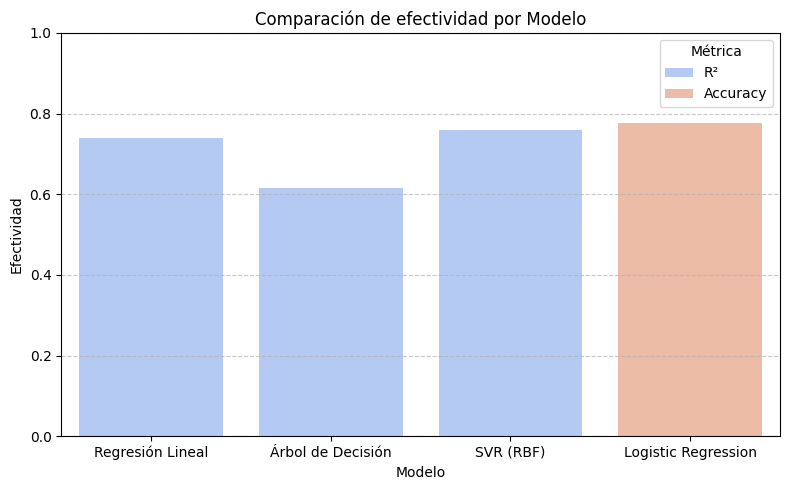

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Crear la tabla comparativa de métricas
data = {
    'Modelo': [
        'Regresión Lineal',
        'Árbol de Decisión',
        'SVR (RBF)',
        'Logistic Regression'
    ],
    'Métrica': [
        'R²', 'R²', 'R²', 'Accuracy'
    ],
    'Valor': [
        0.7388, 0.616, 0.76, 0.776
    ]
}

df_eval = pd.DataFrame(data)
print("📊 Comparación de los 4 Modelos:\n")
print(df_eval)

# Gráfico de comparación de efectividad
plt.figure(figsize=(8, 5))
sns.barplot(x='Modelo', y='Valor', data=df_eval, hue='Métrica', palette='coolwarm')
plt.title('Comparación de efectividad por Modelo')
plt.ylim(0, 1)
plt.ylabel('Efectividad')
plt.xlabel('Modelo')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Tras entrenar y evaluar los cuatro modelos, se observa que el modelo con mayor efectividad es la Logistic Regression, con una precisión (accuracy) de aproximadamente 77.6% en la clasificación de los jugadores como novato, intermedio o experto.
Entre los modelos de regresión, el mejor desempeño lo obtuvo el modelo SVR (RBF), con un coeficiente de determinación
𝑅
2
R
2
  de aproximadamente 0.76, superando a la regresión lineal y al árbol de decisión.
Por lo tanto, considerando las métricas correspondientes a cada tipo de problema, la Logistic Regression es el modelo más efectivo en términos de precisión general para este conjunto de datos.

